# Vehicle Maintenance Logistic Regression Walkthrough

## 0) Setup
Imports the libraries, finds the dataset automatically, and creates a folder where outputs will be saved.

In [1]:
from __future__ import annotations

import json
import re
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from dateutil import parser
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 140


def resolve_paths(start: Path = Path.cwd()) -> tuple[Path, Path]:
    candidates = []
    for p in [start, *start.parents]:
        candidates.append(p)
        candidates.append(p / "vehicle_maintenance_logreg_project")

    candidates.extend(
        [
            Path(r"C:\Users\Dell\Desktop\vehicle_maintenance_logreg_project"),
            Path("/mnt/data/vehicle_maintenance_logreg_project"),
            Path("/mnt/data"),
        ]
    )

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        candidate = Path(candidate)
        key = str(candidate)
        if key not in seen:
            seen.add(key)
            unique_candidates.append(candidate)

    for root in unique_candidates:
        path1 = root / "data" / "vehicle_maintenance_data_unclean.csv"
        path2 = root / "vehicle_maintenance_data_unclean.csv"
        if path1.exists():
            return root, path1
        if path2.exists():
            return root, path2

    raise FileNotFoundError(
        "Could not find vehicle_maintenance_data_unclean.csv. "
        "Place the notebook inside the extracted project folder, "
        "or keep the CSV in a nearby data folder."
    )


PROJECT_DIR, DATA_PATH = resolve_paths()
OUTPUT_DIR = PROJECT_DIR / "notebook_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Dirty dataset path:", DATA_PATH)
print("Notebook output folder:", OUTPUT_DIR)


Project directory: c:\Users\Dell\Desktop\vehicle_maintenance_logreg_project
Dirty dataset path: c:\Users\Dell\Desktop\vehicle_maintenance_logreg_project\data\vehicle_maintenance_data_unclean.csv
Notebook output folder: c:\Users\Dell\Desktop\vehicle_maintenance_logreg_project\notebook_outputs


## 1) Load the dirty dataset
Unclean dataset with duplicates, missing-like markers, inconsistent categories, mixed numeric formats, invalid dates, and outliers.

In [2]:
raw_df = pd.read_csv(DATA_PATH)

print("Raw shape:", raw_df.shape)
display(raw_df.head(10))
display(raw_df.dtypes.rename("raw_dtype").to_frame().T)

Raw shape: (50900, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Motorcycle,57250,Good,3,8,Petrol,Automatic,2500,141262,2023-05-16,2025-06-06,Third,19056,8,2,15.825674946372033,Worn Out,Worn Out,New,1
1,Motorcycle,50221,Good,0,6,Electric,Automatic,2000,137231,2024-02-14,2024-09-20,Third,-2607,4,2,17.42457473669218,Good,Worn Out,Weak,1
2,Truck,42561,Poor,1,9,Diesel,Automatic,800,74066,2023-07-21,2025-12-20,Third,29292,9,0,13.67534277562655,New,New,New,0
3,Van,51607,Average,0,4,Diesel,Automatic,2500,59535,2023-07-13,2025-05-31,Second,14158,2,1,19.59323683655272,Worn Out,Worn Out,New,1
4,Van,74297,Good,1,10,Diesel,Automatic,2000,15966,2023-09-26,99/99/9999,Second,21590,6,3,15.132657818711335,Worn Out,New,New,0
5,Van,30887 km,Poor,0,2,Petrol,Manual,2500,"60,740",2023-06-05,2025-06-03,First,6401,3,1,15.376084419476191,Good,Good,Good,0
6,Bus,79548,Good,5,6,Electric,Automatic,1500,38188,2023-05-04,2025-09-29,Second,28345,7,2,17.941532064804036,Good,New,Weak,1
7,Bus,71076,Average,1,10,petrol,Automatic,1000,149878,2023-11-02,2025-04-18,Second,25418,5,1,10.534125781455693,Worn Out,Good,New,0
8,Bus,68467,Average,1,2,Petrol,Automatic,800,76341,2023-10-14,2025-05-31,Third,10150,9,3,18.2321051420944,New,New,New,1
9,Bus,45696,Good,3,7,Diesel,Manual,1000,39903,2023-11-18,2025-02-15,Second,10330,6,2,10.628755409339387,Good,Good,Good,0


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
raw_dtype,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str


## 2) Quick dirty-data audit
for **auditing** the dirty dataset before we clean it.

In [3]:
MISSING_MARKERS = {
    "",
    "na",
    "n/a",
    "n.a",
    "null",
    "none",
    "nan",
    "unknown",
    "?",
    "not recorded",
}

NUMBER_WORDS = {
    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
    "none": 0,
    "many": 8,
    "multiple": 3,
}

categorical_cols = [
    "Vehicle_Model",
    "Maintenance_History",
    "Fuel_Type",
    "Transmission_Type",
    "Owner_Type",
    "Tire_Condition",
    "Brake_Condition",
    "Battery_Status",
    "Need_Maintenance",
]

numeric_cols = [
    "Mileage",
    "Reported_Issues",
    "Vehicle_Age",
    "Engine_Size",
    "Odometer_Reading",
    "Insurance_Premium",
    "Service_History",
    "Accident_History",
    "Fuel_Efficiency",
]

date_cols = ["Last_Service_Date", "Warranty_Expiry_Date"]


def is_missing_like(value) -> bool:
    if pd.isna(value):
        return True
    return str(value).strip().lower() in MISSING_MARKERS


def preview_top_labels(df: pd.DataFrame, column: str, top_n: int = 12) -> pd.DataFrame:
    return (
        df[column]
        .astype(str)
        .value_counts(dropna=False)
        .head(top_n)
        .rename_axis(column)
        .reset_index(name="count")
    )

### 2.1 Dirty dataset overview

In [4]:
dirty_overview = pd.DataFrame(
    [
        {"metric": "Rows", "value": len(raw_df)},
        {"metric": "Columns", "value": raw_df.shape[1]},
        {"metric": "Exact duplicate rows", "value": int(raw_df.duplicated().sum())},
        {"metric": "Rows with missing-like target labels", "value": int(raw_df["Need_Maintenance"].apply(is_missing_like).sum())},
    ]
)
display(dirty_overview)

,metric,value
0,Rows,50900
1,Columns,20
2,Exact duplicate rows,900
3,Rows with missing-like target labels,182


### 2.2 Missing-like values in the dirty dataset

,column,dirty_missing_like_count
1,Mileage,918
8,Odometer_Reading,816
15,Fuel_Efficiency,724
12,Insurance_Premium,710
3,Reported_Issues,589
13,Service_History,587
14,Accident_History,533
2,Maintenance_History,508
4,Vehicle_Age,453
7,Engine_Size,412


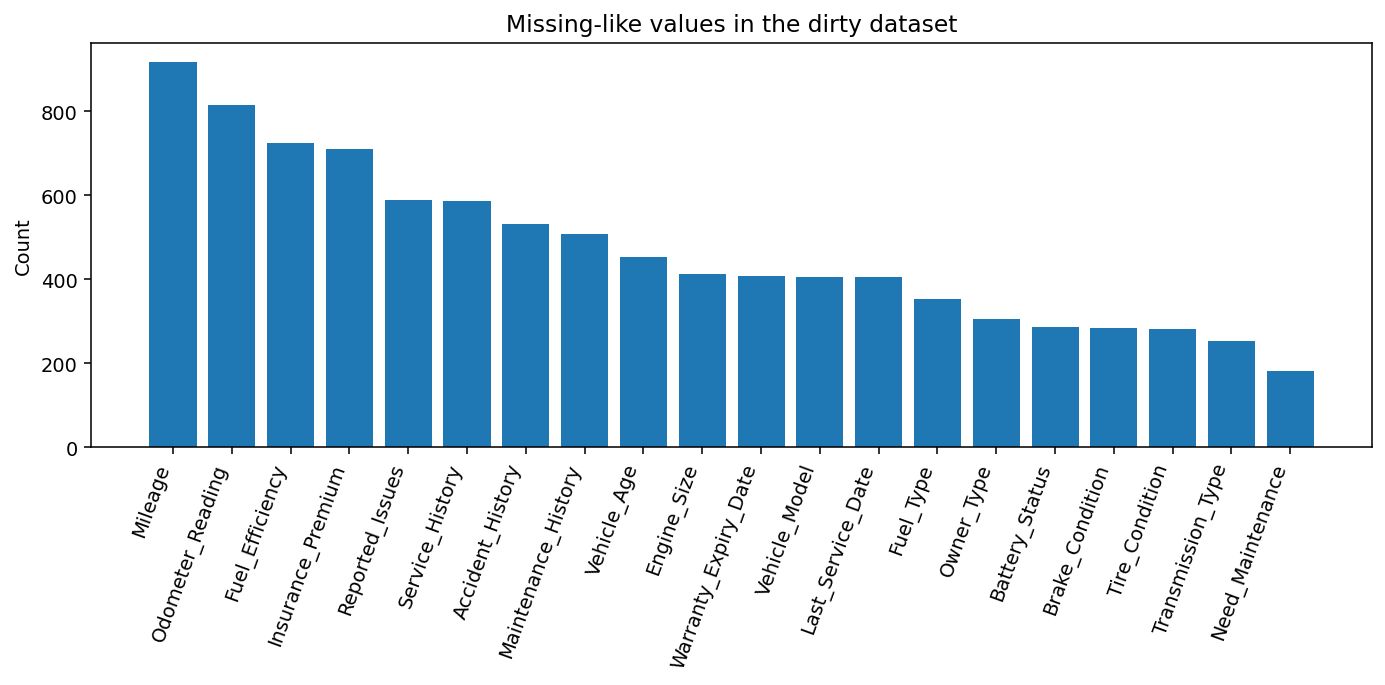

In [5]:
dirty_missing = pd.DataFrame(
    {
        "column": raw_df.columns,
        "dirty_missing_like_count": [int(raw_df[c].apply(is_missing_like).sum()) for c in raw_df.columns],
    }
).sort_values("dirty_missing_like_count", ascending=False)

display(dirty_missing)

plot_df = dirty_missing[dirty_missing["dirty_missing_like_count"] > 0].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(plot_df["column"], plot_df["dirty_missing_like_count"])
ax.set_title("Missing-like values in the dirty dataset")
ax.set_ylabel("Count")
ax.set_xticklabels(plot_df["column"], rotation=70, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dirty_missing_like_counts.png", bbox_inches="tight")
plt.show()

### 2.3 Examples of messy labels before cleaning
The next output makes the problem visible. Notice mixed casing, spelling variants, and target labels such as `yes`, `True`, and `0/1`.

In [6]:
for col in ["Fuel_Type", "Transmission_Type", "Vehicle_Model", "Need_Maintenance"]:
    print(f"\nTop raw labels for {col}")
    display(preview_top_labels(raw_df, col))


Top raw labels for Fuel_Type


,Fuel_Type,count
0,Diesel,16380
1,Petrol,16304
2,Electric,16236
3,NaN,352
4,petrol,192
5,diesel,177
6,Electric,172
7,Diesel,172
8,Petrol,165
9,DSL,164



Top raw labels for Transmission_Type


,Transmission_Type,count
0,Manual,24848
1,Automatic,24780
2,NaN,252
3,Manual,183
4,Auto,183
5,automatic,174
6,MANUAL,163
7,manual,161
8,Automatic,156



Top raw labels for Vehicle_Model


,Vehicle_Model,count
0,Bus,8202
1,Van,8191
2,SUV,8181
3,Motorcycle,8079
4,Truck,8075
5,Car,7940
6,NaN,302
7,car,130
8,Car,116
9,CAR,115



Top raw labels for Need_Maintenance


,Need_Maintenance,count
0,1,40078
1,0,9410
2,1,275
3,yes,246
4,Yes,244
5,True,235
6,NaN,182
7,No,64
8,no,63
9,False,53


## 3) Complete cleaning code
 **full dataset cleaning logic** for this project

In [7]:
from __future__ import annotations

import re
from dataclasses import dataclass
from typing import Any, Dict, Iterable

import numpy as np
import pandas as pd
from dateutil import parser


MISSING_MARKERS = {
    "",
    "na",
    "n/a",
    "n.a",
    "null",
    "none",
    "nan",
    "unknown",
    "?",
    "not recorded",
}

NUMBER_WORDS = {
    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
    "none": 0,
    "many": 8,
    "multiple": 3,
}


@dataclass
class CleaningAudit:
    raw_rows: int
    duplicate_rows_removed: int
    rows_after_dedup: int
    rows_with_missing_target_dropped: int
    final_modeling_rows: int
    date_inconsistencies_fixed: int

    def as_dict(self) -> Dict[str, int]:
        return {
            "raw_rows": self.raw_rows,
            "duplicate_rows_removed": self.duplicate_rows_removed,
            "rows_after_dedup": self.rows_after_dedup,
            "rows_with_missing_target_dropped": self.rows_with_missing_target_dropped,
            "final_modeling_rows": self.final_modeling_rows,
            "date_inconsistencies_fixed": self.date_inconsistencies_fixed,
        }


def _normalize_string(value: Any) -> str | float:
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.lower() in MISSING_MARKERS:
        return np.nan
    return text


def _normalize_space(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip().lower()


def map_vehicle_model(value: Any) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "car": "Car",
        "suv": "SUV",
        "truck": "Truck",
        "van": "Van",
        "bus": "Bus",
        "motorcycle": "Motorcycle",
        "motor cycle": "Motorcycle",
    }
    return mapping.get(_normalize_space(str(text)), np.nan)


def map_maintenance_history(value: Any) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "good": "Good",
        "average": "Average",
        "avg": "Average",
        "poor": "Poor",
        "p00r": "Poor",
    }
    return mapping.get(_normalize_space(str(text)), np.nan)


def map_fuel_type(value: Any) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "petrol": "Petrol",
        "gasoline": "Petrol",
        "diesel": "Diesel",
        "dsl": "Diesel",
        "electric": "Electric",
        "ev": "Electric",
        "hybrid": "Other",
        "cng": "Other",
    }
    return mapping.get(_normalize_space(str(text)), np.nan)


def map_transmission(value: Any) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "manual": "Manual",
        "automatic": "Automatic",
        "auto": "Automatic",
    }
    return mapping.get(_normalize_space(str(text)), np.nan)


def map_owner_type(value: Any) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "first": "First",
        "1st": "First",
        "first owner": "First",
        "second": "Second",
        "2nd": "Second",
        "second owner": "Second",
        "third": "Third",
        "3rd": "Third",
        "third owner": "Third",
    }
    return mapping.get(_normalize_space(str(text)), np.nan)


def map_condition(value: Any, weak_allowed: bool = False) -> str | float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    cleaned = re.sub(r"[_-]+", " ", str(text))
    cleaned = _normalize_space(cleaned)
    if weak_allowed:
        mapping = {"new": "New", "good": "Good", "weak": "Weak"}
    else:
        mapping = {"new": "New", "good": "Good", "worn out": "Worn Out"}
    return mapping.get(cleaned, np.nan)


def map_target(value: Any) -> float:
    text = _normalize_string(value)
    if pd.isna(text):
        return np.nan
    mapping = {
        "1": 1.0,
        "yes": 1.0,
        "true": 1.0,
        "0": 0.0,
        "no": 0.0,
        "false": 0.0,
    }
    return mapping.get(str(text).strip().lower(), np.nan)


def parse_numeric(value: Any, field: str | None = None) -> float:
    if pd.isna(value):
        return np.nan

    text = str(value).strip()
    if text.lower() in MISSING_MARKERS:
        return np.nan

    lowered = text.lower().strip()
    if lowered in NUMBER_WORDS:
        return float(NUMBER_WORDS[lowered])

    if re.fullmatch(r"-?\d+,\d+", lowered):
        lowered = lowered.replace(",", ".")

    has_liter_unit = bool(re.search(r"(?<![a-z])[0-9.]+\s*l\b", lowered)) or lowered.endswith("l")

    cleaned = lowered.replace("$", "").replace(",", "")
    cleaned = cleaned.replace("km/l", "").replace("km", "").replace("cc", "").strip()
    cleaned = cleaned.replace("l", "").strip()

    try:
        number = float(cleaned)
    except ValueError:
        return np.nan

    if field == "Engine_Size" and has_liter_unit and abs(number) <= 10:
        number *= 1000.0

    return number


def parse_date(value: Any) -> pd.Timestamp | pd.NaT:
    if pd.isna(value):
        return pd.NaT

    text = str(value).strip()
    if text.lower() in MISSING_MARKERS:
        return pd.NaT

    for dayfirst in (False, True):
        try:
            parsed = parser.parse(text, dayfirst=dayfirst, fuzzy=False)
            if 2000 <= parsed.year <= 2030:
                return pd.Timestamp(parsed.date())
        except Exception:
            continue

    return pd.NaT


VALID_RANGES = {
    "Mileage": (0, 300000),
    "Reported_Issues": (0, 20),
    "Vehicle_Age": (0, 30),
    "Engine_Size": (500, 8000),
    "Odometer_Reading": (0, 500000),
    "Insurance_Premium": (0, 100000),
    "Service_History": (0, 30),
    "Accident_History": (0, 20),
    "Fuel_Efficiency": (5, 40),
}


def clean_dataset(raw_df: pd.DataFrame) -> tuple[pd.DataFrame, CleaningAudit]:
    df = raw_df.copy()
    raw_rows = len(df)
    duplicate_rows_removed = int(df.duplicated().sum())
    df = df.drop_duplicates().reset_index(drop=True)

    df["Vehicle_Model"] = df["Vehicle_Model"].apply(map_vehicle_model)
    df["Maintenance_History"] = df["Maintenance_History"].apply(map_maintenance_history)
    df["Fuel_Type"] = df["Fuel_Type"].apply(map_fuel_type)
    df["Transmission_Type"] = df["Transmission_Type"].apply(map_transmission)
    df["Owner_Type"] = df["Owner_Type"].apply(map_owner_type)
    df["Tire_Condition"] = df["Tire_Condition"].apply(lambda x: map_condition(x, weak_allowed=False))
    df["Brake_Condition"] = df["Brake_Condition"].apply(lambda x: map_condition(x, weak_allowed=False))
    df["Battery_Status"] = df["Battery_Status"].apply(lambda x: map_condition(x, weak_allowed=True))
    df["Need_Maintenance"] = df["Need_Maintenance"].apply(map_target)

    numeric_columns = [
        "Mileage",
        "Reported_Issues",
        "Vehicle_Age",
        "Engine_Size",
        "Odometer_Reading",
        "Insurance_Premium",
        "Service_History",
        "Accident_History",
        "Fuel_Efficiency",
    ]
    for column in numeric_columns:
        df[column] = df[column].apply(lambda x, c=column: parse_numeric(x, field=c))
        lower, upper = VALID_RANGES[column]
        df.loc[(df[column] < lower) | (df[column] > upper), column] = np.nan

    date_columns = ["Last_Service_Date", "Warranty_Expiry_Date"]
    for column in date_columns:
        df[column] = df[column].apply(parse_date)

    inconsistent_dates = (
        df["Warranty_Expiry_Date"].notna()
        & df["Last_Service_Date"].notna()
        & (df["Warranty_Expiry_Date"] < df["Last_Service_Date"])
    )
    inconsistent_count = int(inconsistent_dates.sum())
    df.loc[inconsistent_dates, "Warranty_Expiry_Date"] = pd.NaT

    missing_target_rows = int(df["Need_Maintenance"].isna().sum())
    df = df.dropna(subset=["Need_Maintenance"]).reset_index(drop=True)
    df["Need_Maintenance"] = df["Need_Maintenance"].astype(int)

    audit = CleaningAudit(
        raw_rows=raw_rows,
        duplicate_rows_removed=duplicate_rows_removed,
        rows_after_dedup=raw_rows - duplicate_rows_removed,
        rows_with_missing_target_dropped=missing_target_rows,
        final_modeling_rows=len(df),
        date_inconsistencies_fixed=inconsistent_count,
    )
    return df, audit

## 4) Apply the cleaning pipeline
This step removes duplicates, standardizes missing values, normalizes categories, parses numbers and dates, fixes invalid date logic, and drops rows whose target label cannot be recovered.

In [8]:
cleaned_df, cleaning_audit = clean_dataset(raw_df)

display(pd.DataFrame([cleaning_audit.as_dict()]))
print("Cleaned shape:", cleaned_df.shape)
display(cleaned_df.head(10))

,raw_rows,duplicate_rows_removed,rows_after_dedup,rows_with_missing_target_dropped,final_modeling_rows,date_inconsistencies_fixed
0,50900,900,50000,180,49820,239


Cleaned shape: (49820, 20)


,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Motorcycle,57250.0,Good,3.0,8.0,Petrol,Automatic,2500.0,141262.00,2023-05-16,2025-06-06,Third,19056.0,8.0,2.0,15.825675,Worn Out,Worn Out,New,1
1,Motorcycle,50221.0,Good,0.0,6.0,Electric,Automatic,2000.0,137231.00,2024-02-14,2024-09-20,Third,NaN,4.0,2.0,17.424575,Good,Worn Out,Weak,1
2,Truck,42561.0,Poor,1.0,9.0,Diesel,Automatic,800.0,74066.00,2023-07-21,2025-12-20,Third,29292.0,9.0,0.0,13.675343,New,New,New,0
3,Van,51607.0,Average,0.0,4.0,Diesel,Automatic,2500.0,59535.00,2023-07-13,2025-05-31,Second,14158.0,2.0,1.0,19.593237,Worn Out,Worn Out,New,1
4,Van,74297.0,Good,1.0,10.0,Diesel,Automatic,2000.0,15966.00,2023-09-26,NaT,Second,21590.0,6.0,3.0,15.132658,Worn Out,New,New,0
5,Van,30887.0,Poor,0.0,2.0,Petrol,Manual,2500.0,60.74,2023-06-05,2025-06-03,First,6401.0,3.0,1.0,15.376084,Good,Good,Good,0
6,Bus,79548.0,Good,5.0,6.0,Electric,Automatic,1500.0,38188.00,2023-05-04,2025-09-29,Second,28345.0,7.0,2.0,17.941532,Good,New,Weak,1
7,Bus,71076.0,Average,1.0,10.0,Petrol,Automatic,1000.0,149878.00,2023-11-02,2025-04-18,Second,25418.0,5.0,1.0,10.534126,Worn Out,Good,New,0
8,Bus,68467.0,Average,1.0,2.0,Petrol,Automatic,800.0,76341.00,2023-10-14,2025-05-31,Third,10150.0,9.0,3.0,18.232105,New,New,New,1
9,Bus,45696.0,Good,3.0,7.0,Diesel,Manual,1000.0,39903.00,2023-11-18,2025-02-15,Second,10330.0,6.0,2.0,10.628755,Good,Good,Good,0


## 5) Compare the dirty and cleaned datasets
 **What changed after cleaning?**

In [9]:
def count_raw_numeric_issues(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in numeric_cols:
        parsed = df[col].apply(lambda x, c=col: parse_numeric(x, field=c))
        lower, upper = VALID_RANGES[col]
        rows.append(
            {
                "column": col,
                "dirty_missing_or_unparsed": int(parsed.isna().sum()),
                "dirty_out_of_range": int(((parsed < lower) | (parsed > upper)).fillna(False).sum()),
                "clean_missing_after_rules": int(cleaned_df[col].isna().sum()),
                "clean_out_of_range": int(((cleaned_df[col] < lower) | (cleaned_df[col] > upper)).fillna(False).sum()),
            }
        )
    return pd.DataFrame(rows)


def count_date_issues(df: pd.DataFrame) -> tuple[pd.DataFrame, int, int]:
    parsed_dates = {}
    rows = []
    for col in date_cols:
        parsed = df[col].apply(parse_date)
        parsed_dates[col] = parsed
        rows.append(
            {
                "column": col,
                "dirty_missing_or_invalid": int(parsed.isna().sum()),
                "clean_missing_after_rules": int(cleaned_df[col].isna().sum()),
            }
        )

    dirty_inconsistent = int(
        (
            parsed_dates["Warranty_Expiry_Date"].notna()
            & parsed_dates["Last_Service_Date"].notna()
            & (parsed_dates["Warranty_Expiry_Date"] < parsed_dates["Last_Service_Date"])
        ).sum()
    )
    clean_inconsistent = int(
        (
            cleaned_df["Warranty_Expiry_Date"].notna()
            & cleaned_df["Last_Service_Date"].notna()
            & (cleaned_df["Warranty_Expiry_Date"] < cleaned_df["Last_Service_Date"])
        ).sum()
    )
    return pd.DataFrame(rows), dirty_inconsistent, clean_inconsistent

### 5.1 Overall before-vs-after comparison

In [10]:
date_quality_df, dirty_bad_date_order, clean_bad_date_order = count_date_issues(raw_df)

overall_compare = pd.DataFrame(
    [
        {"metric": "Rows", "dirty_dataset": len(raw_df), "cleaned_dataset": len(cleaned_df)},
        {"metric": "Columns", "dirty_dataset": raw_df.shape[1], "cleaned_dataset": cleaned_df.shape[1]},
        {"metric": "Exact duplicate rows", "dirty_dataset": int(raw_df.duplicated().sum()), "cleaned_dataset": int(cleaned_df.duplicated().sum())},
        {"metric": "Rows with missing/invalid target", "dirty_dataset": int(raw_df["Need_Maintenance"].apply(is_missing_like).sum()), "cleaned_dataset": int(cleaned_df["Need_Maintenance"].isna().sum())},
        {"metric": "Warranty earlier than last service", "dirty_dataset": dirty_bad_date_order, "cleaned_dataset": clean_bad_date_order},
    ]
)

display(overall_compare)
overall_compare.to_csv(OUTPUT_DIR / "overall_before_after_comparison.csv", index=False)

,metric,dirty_dataset,cleaned_dataset
0,Rows,50900,49820
1,Columns,20,20
2,Exact duplicate rows,900,0
3,Rows with missing/invalid target,182,0
4,Warranty earlier than last service,246,0


### 5.2 Unique category levels before and after cleaning
A successful cleaning step should collapse messy labels into a much smaller, valid label set.

,column,dirty_unique_labels,clean_unique_labels
0,Vehicle_Model,25,6
2,Fuel_Type,14,4
1,Maintenance_History,13,3
6,Brake_Condition,13,3
5,Tire_Condition,13,3
7,Battery_Status,13,3
4,Owner_Type,12,3
8,Need_Maintenance,10,2
3,Transmission_Type,8,2


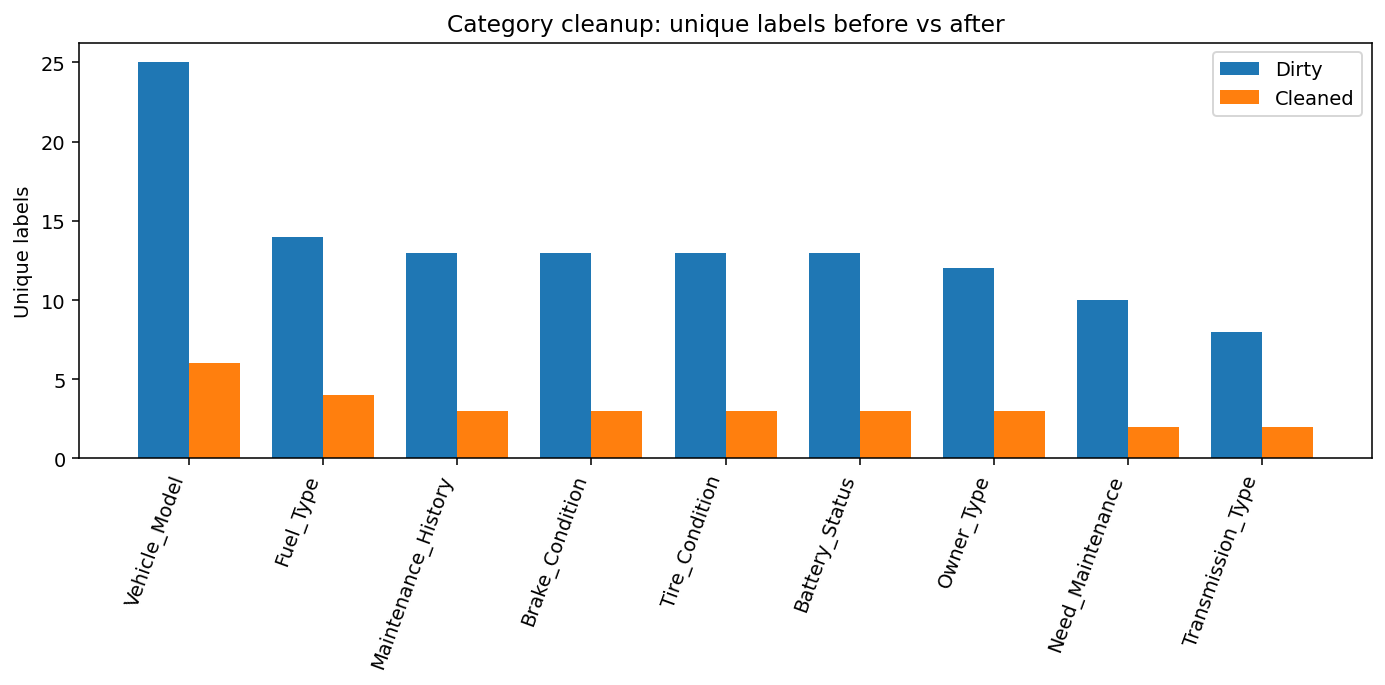

In [11]:
category_compare = pd.DataFrame(
    {
        "column": categorical_cols,
        "dirty_unique_labels": [raw_df[c].astype(str).nunique(dropna=True) for c in categorical_cols],
        "clean_unique_labels": [cleaned_df[c].nunique(dropna=True) for c in categorical_cols],
    }
).sort_values("dirty_unique_labels", ascending=False)

display(category_compare)
category_compare.to_csv(OUTPUT_DIR / "category_unique_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(category_compare))
width = 0.38
ax.bar(x - width / 2, category_compare["dirty_unique_labels"], width=width, label="Dirty")
ax.bar(x + width / 2, category_compare["clean_unique_labels"], width=width, label="Cleaned")
ax.set_xticks(x, category_compare["column"], rotation=70, ha="right")
ax.set_ylabel("Unique labels")
ax.set_title("Category cleanup: unique labels before vs after")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "category_unique_before_after.png", bbox_inches="tight")
plt.show()

### 5.3 Numeric quality before and after cleaning
This shows how many numeric values were either unreadable or outside the valid range before cleaning, versus after cleaning.

,column,dirty_missing_or_unparsed,dirty_out_of_range,clean_missing_after_rules,clean_out_of_range
0,Mileage,918,335,1230,0
1,Reported_Issues,589,122,690,0
2,Vehicle_Age,453,154,594,0
3,Engine_Size,412,103,503,0
4,Odometer_Reading,816,247,1040,0
5,Insurance_Premium,710,229,920,0
6,Service_History,587,122,692,0
7,Accident_History,533,100,617,0
8,Fuel_Efficiency,724,243,945,0


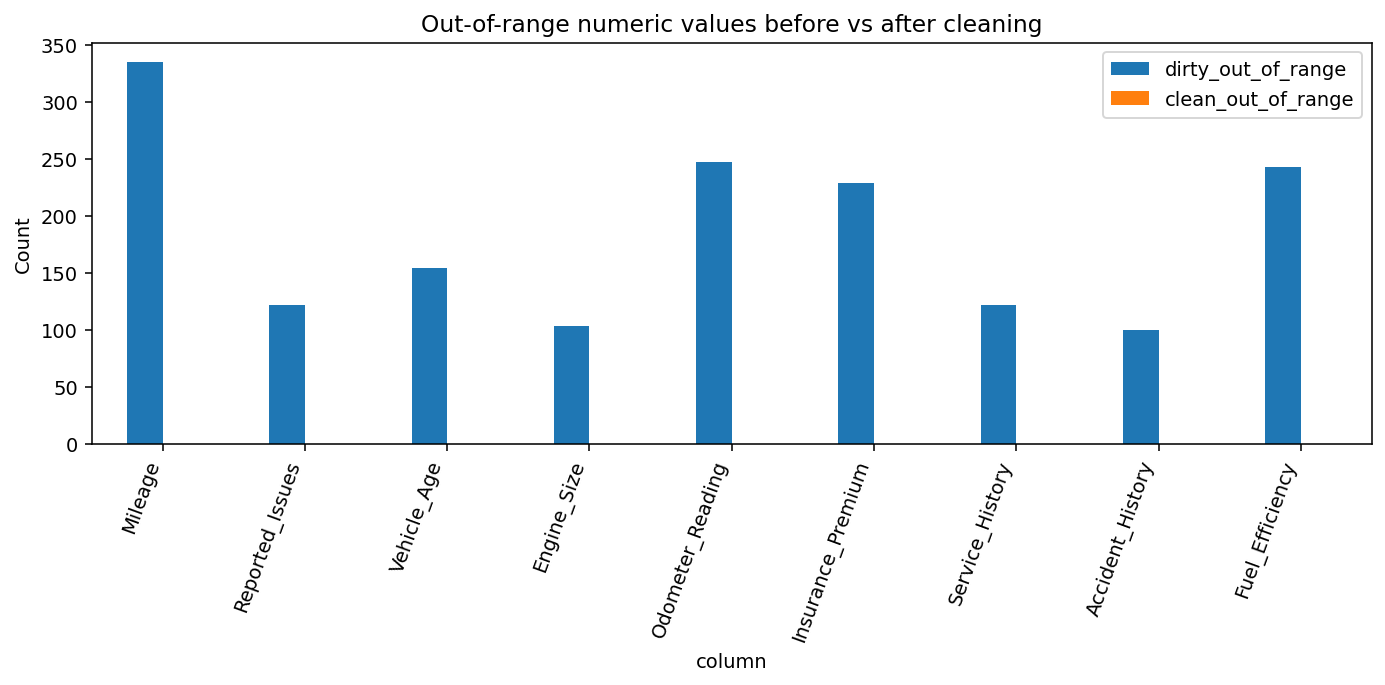

In [12]:
numeric_quality = count_raw_numeric_issues(raw_df)
display(numeric_quality)
numeric_quality.to_csv(OUTPUT_DIR / "numeric_quality_comparison.csv", index=False)

plot_numeric = numeric_quality.set_index("column")[["dirty_out_of_range", "clean_out_of_range"]]

fig, ax = plt.subplots(figsize=(10, 5))
plot_numeric.plot(kind="bar", ax=ax)
ax.set_title("Out-of-range numeric values before vs after cleaning")
ax.set_ylabel("Count")
ax.set_xticklabels(plot_numeric.index, rotation=70, ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "numeric_out_of_range_before_after.png", bbox_inches="tight")
plt.show()

### 5.4 Date quality before and after cleaning

,column,dirty_missing_or_invalid,clean_missing_after_rules
0,Last_Service_Date,527,518
1,Warranty_Expiry_Date,519,743


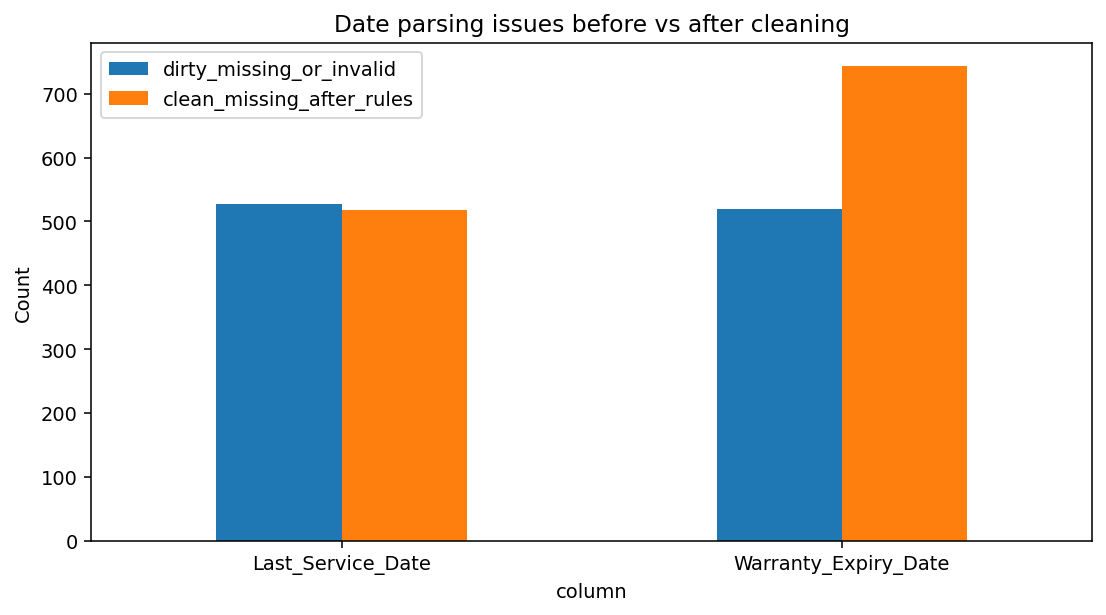

In [13]:
display(date_quality_df)
date_quality_df.to_csv(OUTPUT_DIR / "date_quality_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
date_plot = date_quality_df.set_index("column")
date_plot.plot(kind="bar", ax=ax)
ax.set_title("Date parsing issues before vs after cleaning")
ax.set_ylabel("Count")
ax.set_xticklabels(date_plot.index, rotation=0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "date_quality_before_after.png", bbox_inches="tight")
plt.show()

### 5.5 category labels before and after cleaning

In [14]:
for col in ["Fuel_Type", "Transmission_Type", "Vehicle_Model", "Need_Maintenance"]:
    print(f"\n{col} BEFORE cleaning")
    display(preview_top_labels(raw_df, col))
    print(f"{col} AFTER cleaning")
    display(cleaned_df[col].astype(str).value_counts(dropna=False).head(12).rename_axis(col).reset_index(name="count"))


Fuel_Type BEFORE cleaning


,Fuel_Type,count
0,Diesel,16380
1,Petrol,16304
2,Electric,16236
3,NaN,352
4,petrol,192
5,diesel,177
6,Electric,172
7,Diesel,172
8,Petrol,165
9,DSL,164


Fuel_Type AFTER cleaning


,Fuel_Type,count
0,Diesel,16529
1,Petrol,16463
2,Electric,16360
3,NaN,349
4,Other,119



Transmission_Type BEFORE cleaning


...

,Vehicle_Model,count
0,Van,8308
1,Bus,8308
2,SUV,8272
3,Truck,8225
4,Motorcycle,8190
5,Car,8120
6,NaN,397



Need_Maintenance BEFORE cleaning


,Need_Maintenance,count
0,1,40078
1,0,9410
2,1,275
3,yes,246
4,Yes,244
5,True,235
6,NaN,182
7,No,64
8,no,63
9,False,53


Need_Maintenance AFTER cleaning


,Need_Maintenance,count
0,1,40341
1,0,9479


### 5.6 raw vs cleaned numeric distribution
The raw data contains messy formatting and outliers. After cleaning, the distribution becomes more realistic.

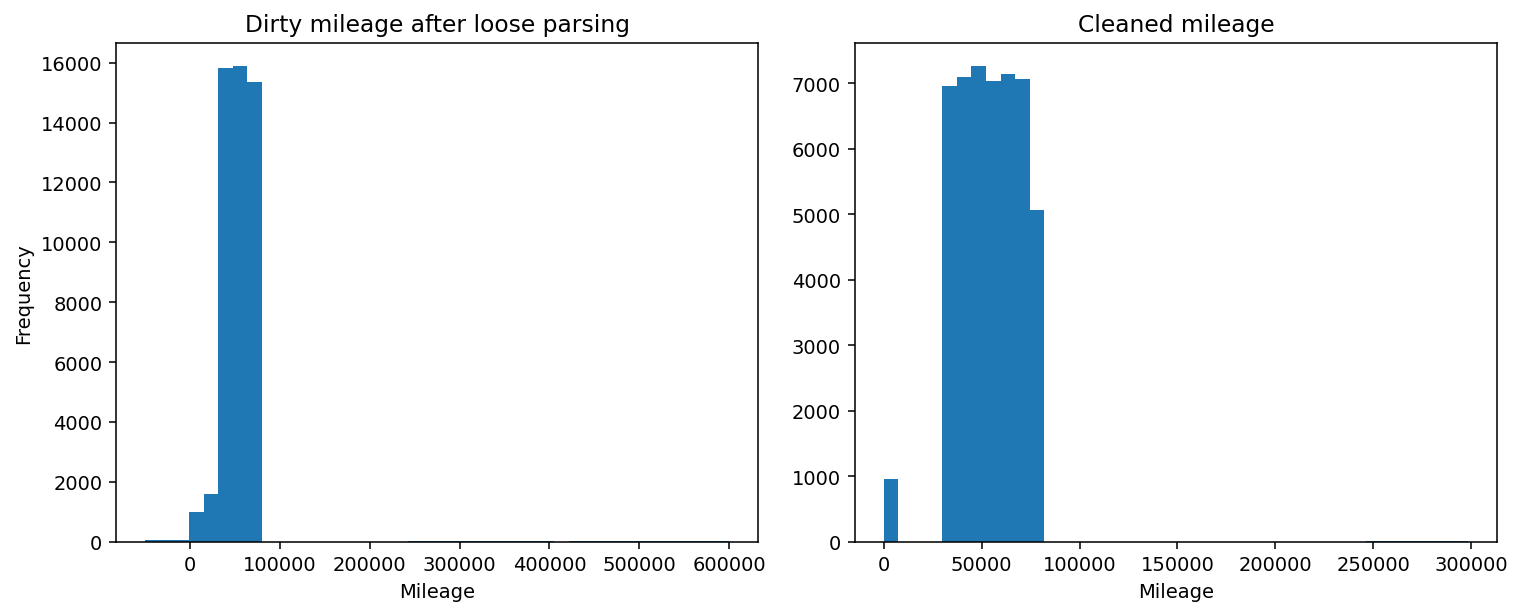

In [15]:
raw_mileage_parsed = raw_df["Mileage"].apply(lambda x: parse_numeric(x, field="Mileage"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(raw_mileage_parsed.dropna(), bins=40)
axes[0].set_title("Dirty mileage after loose parsing")
axes[0].set_xlabel("Mileage")
axes[0].set_ylabel("Frequency")

axes[1].hist(cleaned_df["Mileage"].dropna(), bins=40)
axes[1].set_title("Cleaned mileage")
axes[1].set_xlabel("Mileage")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "dirty_vs_cleaned_mileage.png", bbox_inches="tight")
plt.show()

In [16]:
display(Markdown(
    f'''
### What changes can we see after cleaning?

- **{cleaning_audit.duplicate_rows_removed:,} exact duplicates** were removed.
- **{cleaning_audit.rows_with_missing_target_dropped:,} rows** were dropped because the target label could not be recovered.
- Invalid target-label variants were standardized into just **2 valid classes**: 0 and 1.
- Category explosion was reduced. For example:
  - Fuel type: **{int(category_compare.loc[category_compare["column"]=="Fuel_Type", "dirty_unique_labels"].iloc[0])} -> {int(category_compare.loc[category_compare["column"]=="Fuel_Type", "clean_unique_labels"].iloc[0])}**
  - Transmission type: **{int(category_compare.loc[category_compare["column"]=="Transmission_Type", "dirty_unique_labels"].iloc[0])} -> {int(category_compare.loc[category_compare["column"]=="Transmission_Type", "clean_unique_labels"].iloc[0])}**
  - Vehicle model: **{int(category_compare.loc[category_compare["column"]=="Vehicle_Model", "dirty_unique_labels"].iloc[0])} -> {int(category_compare.loc[category_compare["column"]=="Vehicle_Model", "clean_unique_labels"].iloc[0])}**
- Numeric columns no longer contain impossible negative values or extreme out-of-range values after the cleaning rules.
- Date logic improved: records with warranty dates earlier than the last service date were fixed by setting the invalid warranty date to missing.
'''
))


### What changes can we see after cleaning?

- **900 exact duplicates** were removed.
- **180 rows** were dropped because the target label could not be recovered.
- Invalid target-label variants were standardized into just **2 valid classes**: 0 and 1.
- Category explosion was reduced. For example:
  - Fuel type: **14 -> 4**
  - Transmission type: **8 -> 2**
  - Vehicle model: **25 -> 6**
- Numeric columns no longer contain impossible negative values or extreme out-of-range values after the cleaning rules.
- Date logic improved: records with warranty dates earlier than the last service date were fixed by setting the invalid warranty date to missing.


## 6)  feature-engineering 
**full feature-engineering logic** used in the project.

In [17]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd


BASE_NUMERIC = [
    "Mileage",
    "Reported_Issues",
    "Vehicle_Age",
    "Engine_Size",
    "Odometer_Reading",
    "Insurance_Premium",
    "Service_History",
    "Accident_History",
    "Fuel_Efficiency",
    "days_since_last_service",
    "days_to_warranty_expiry",
]

BASE_CATEGORICAL = [
    "Vehicle_Model",
    "Maintenance_History",
    "Fuel_Type",
    "Transmission_Type",
    "Owner_Type",
    "Tire_Condition",
    "Brake_Condition",
    "Battery_Status",
]

ENGINEERED_NUMERIC = [
    "warranty_expired_flag",
    "mileage_per_year",
    "issues_per_year",
    "service_per_year",
    "accidents_per_year",
    "condition_score",
]


@dataclass
class FeatureBundle:
    name: str
    X: pd.DataFrame
    y: pd.Series


def add_engineered_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Timestamp]:
    engineered = df.copy()
    reference_date = engineered["Last_Service_Date"].max()

    engineered["days_since_last_service"] = (reference_date - engineered["Last_Service_Date"]).dt.days
    engineered["days_to_warranty_expiry"] = (engineered["Warranty_Expiry_Date"] - reference_date).dt.days
    engineered["warranty_expired_flag"] = (engineered["days_to_warranty_expiry"] < 0).astype(float)

    vehicle_age = engineered["Vehicle_Age"].replace(0, np.nan)
    engineered["mileage_per_year"] = engineered["Mileage"] / vehicle_age
    engineered["issues_per_year"] = engineered["Reported_Issues"] / vehicle_age
    engineered["service_per_year"] = engineered["Service_History"] / vehicle_age
    engineered["accidents_per_year"] = engineered["Accident_History"] / vehicle_age

    tire_map = {"New": 0, "Good": 1, "Worn Out": 2}
    brake_map = {"New": 0, "Good": 1, "Worn Out": 2}
    battery_map = {"New": 0, "Good": 1, "Weak": 2}
    engineered["tire_condition_score"] = engineered["Tire_Condition"].map(tire_map)
    engineered["brake_condition_score"] = engineered["Brake_Condition"].map(brake_map)
    engineered["battery_condition_score"] = engineered["Battery_Status"].map(battery_map)
    engineered["condition_score"] = engineered[
        ["tire_condition_score", "brake_condition_score", "battery_condition_score"]
    ].sum(axis=1, min_count=1)

    return engineered, reference_date


def build_feature_bundles(df: pd.DataFrame) -> tuple[dict[str, FeatureBundle], pd.Timestamp]:
    engineered_df, reference_date = add_engineered_features(df)
    target = "Need_Maintenance"

    baseline_columns = BASE_NUMERIC + BASE_CATEGORICAL
    full_columns = BASE_NUMERIC + ENGINEERED_NUMERIC + BASE_CATEGORICAL
    leakage_columns = [
        column
        for column in full_columns
        if column not in {"Tire_Condition", "Brake_Condition", "Battery_Status", "condition_score"}
    ]

    bundles = {
        "baseline_cleaned_lr": FeatureBundle(
            name="baseline_cleaned_lr",
            X=engineered_df[baseline_columns].copy(),
            y=engineered_df[target].copy(),
        ),
        "engineered_full_lr": FeatureBundle(
            name="engineered_full_lr",
            X=engineered_df[full_columns].copy(),
            y=engineered_df[target].copy(),
        ),
        "leakage_aware_lr": FeatureBundle(
            name="leakage_aware_lr",
            X=engineered_df[leakage_columns].copy(),
            y=engineered_df[target].copy(),
        ),
    }
    return bundles, reference_date

## 7) Apply feature engineering
Temporal and usage-intensity features which is created and finally the result is inspected.

In [18]:
engineered_df, reference_date = add_engineered_features(cleaned_df)

engineered_only_cols = [
    "days_since_last_service",
    "days_to_warranty_expiry",
    "warranty_expired_flag",
    "mileage_per_year",
    "issues_per_year",
    "service_per_year",
    "accidents_per_year",
    "condition_score",
]

print("Reference date used for temporal features:", reference_date.date())
display(engineered_df[engineered_only_cols + ["Need_Maintenance"]].head(10))

Reference date used for temporal features: 2025-01-15


,days_since_last_service,days_to_warranty_expiry,warranty_expired_flag,mileage_per_year,issues_per_year,service_per_year,accidents_per_year,condition_score,Need_Maintenance
0,610.0,142.0,0.0,7156.250000,0.375000,1.000000,0.250000,4.0,1
1,336.0,-117.0,1.0,8370.166667,0.000000,0.666667,0.333333,5.0,1
2,544.0,339.0,0.0,4729.000000,0.111111,1.000000,0.000000,0.0,0
3,552.0,136.0,0.0,12901.750000,0.000000,0.500000,0.250000,4.0,1
4,477.0,NaN,0.0,7429.700000,0.100000,0.600000,0.300000,2.0,0
5,590.0,139.0,0.0,15443.500000,0.000000,1.500000,0.500000,3.0,0
6,622.0,257.0,0.0,13258.000000,0.833333,1.166667,0.333333,3.0,1
7,440.0,93.0,0.0,7107.600000,0.100000,0.500000,0.100000,3.0,0
8,459.0,136.0,0.0,34233.500000,0.500000,4.500000,1.500000,0.0,1
9,424.0,31.0,0.0,6528.000000,0.428571,0.857143,0.285714,3.0,0


### 7.1 Average engineered-feature values by class
This helps show whether the engineered features separate vehicles that need maintenance from those that do not.

Need_Maintenance,0,1
days_since_last_service,489.38,489.40
days_to_warranty_expiry,90.14,86.33
warranty_expired_flag,0.36,0.37
mileage_per_year,15850.34,15845.41
issues_per_year,0.33,0.83
service_per_year,1.43,1.66
accidents_per_year,0.38,0.46
condition_score,1.99,3.21


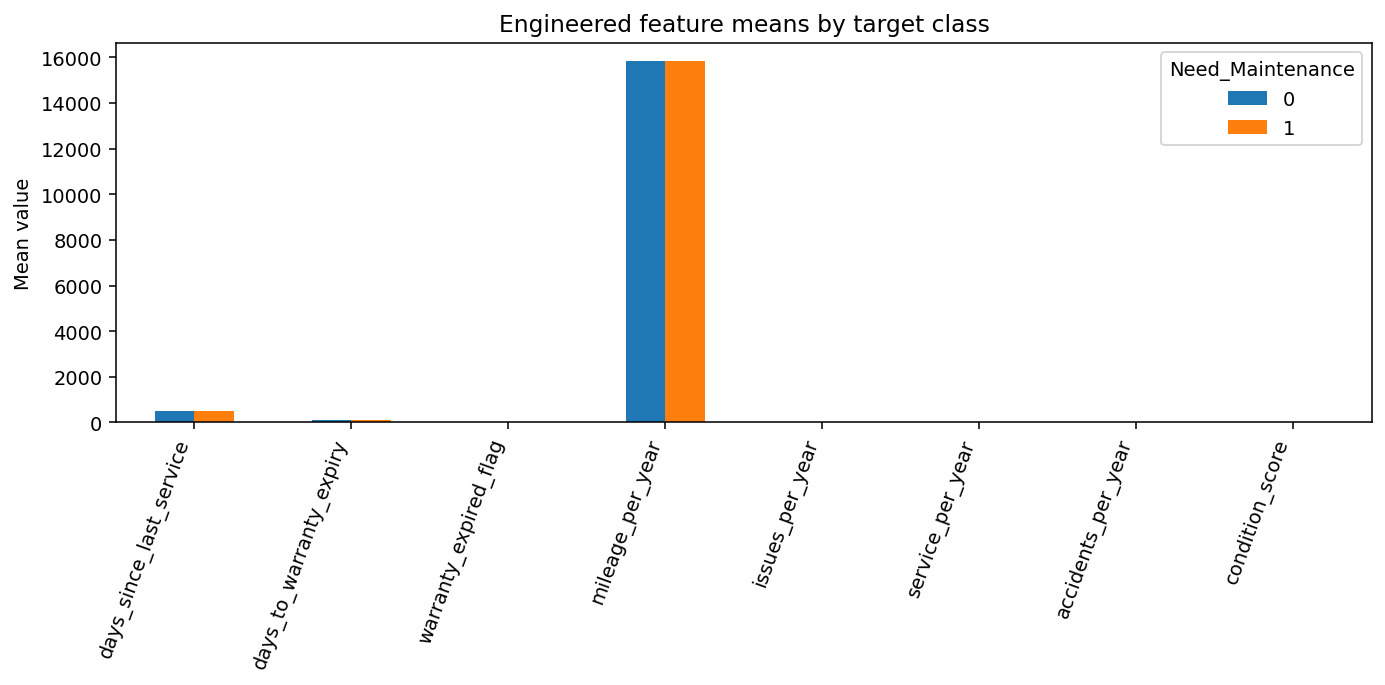

In [19]:
engineered_group_means = engineered_df.groupby("Need_Maintenance")[engineered_only_cols].mean().T
display(engineered_group_means.round(2))
engineered_group_means.to_csv(OUTPUT_DIR / "engineered_feature_group_means.csv")

fig, ax = plt.subplots(figsize=(10, 5))
engineered_group_means.plot(kind="bar", ax=ax)
ax.set_title("Engineered feature means by target class")
ax.set_ylabel("Mean value")
ax.set_xticklabels(engineered_group_means.index, rotation=70, ha="right")
ax.legend(title="Need_Maintenance")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "engineered_feature_means_by_target.png", bbox_inches="tight")
plt.show()

## 8) Logistic Regression modeling
To train, Validate, and evaluate the models.

In [20]:
RISK_BINS = [-np.inf, 0.40, 0.70, np.inf]
RISK_LABELS = ["Low", "Medium", "High"]


@dataclass
class ThresholdInfo:
    threshold: float
    precision: float
    recall: float
    f1: float


def split_data(X: pd.DataFrame, y: pd.Series, random_state: int = 42):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=random_state
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.20, stratify=y_train_val, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_pipeline(X: pd.DataFrame) -> Pipeline:
    numeric_columns = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_columns = [c for c in X.columns if c not in numeric_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        C=1.0,
        random_state=42,
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


def search_threshold(y_true: pd.Series, probabilities: np.ndarray):
    thresholds = np.linspace(0.20, 0.80, 121)
    rows = []
    best_row = None

    for threshold in thresholds:
        preds = (probabilities >= threshold).astype(int)
        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)
        f1 = f1_score(y_true, preds, zero_division=0)

        candidate = {
            "threshold": float(threshold),
            "precision": float(precision),
            "recall": float(recall),
            "f1": float(f1),
        }
        rows.append(candidate)

        score = (round(f1, 6), round(recall, 6), -abs(threshold - 0.50))
        if best_row is None or score > best_row[0]:
            best_row = (score, candidate)

    return ThresholdInfo(**best_row[1]), pd.DataFrame(rows)


def evaluate_probability_metrics(y_true: pd.Series, probabilities: np.ndarray, threshold: float):
    preds = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, preds)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "brier_score": float(brier_score_loss(y_true, probabilities)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def get_coefficients(pipeline: Pipeline) -> pd.DataFrame:
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    coefficients = model.coef_.ravel()
    coef_df = pd.DataFrame({"feature": feature_names, "coefficient": coefficients})
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    return coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)


def build_risk_band_summary(y_true: pd.Series, probabilities: np.ndarray, model_name: str) -> pd.DataFrame:
    band_df = pd.DataFrame(
        {
            "model": model_name,
            "probability": probabilities,
            "band": pd.cut(probabilities, bins=RISK_BINS, labels=RISK_LABELS),
            "actual": y_true.to_numpy(),
        }
    )
    summary = (
        band_df.groupby(["model", "band"], observed=False)
        .agg(
            vehicles=("actual", "size"),
            avg_probability=("probability", "mean"),
            actual_positive_rate=("actual", "mean"),
        )
        .reset_index()
    )
    return summary


def run_bundle(bundle_name: str, X: pd.DataFrame, y: pd.Series) -> dict:
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
    pipeline = build_pipeline(X)
    pipeline.fit(X_train, y_train)

    val_prob = pipeline.predict_proba(X_val)[:, 1]
    test_prob = pipeline.predict_proba(X_test)[:, 1]

    threshold_info, threshold_table = search_threshold(y_val, val_prob)
    tuned_metrics = evaluate_probability_metrics(y_test, test_prob, threshold_info.threshold)
    default_metrics = evaluate_probability_metrics(y_test, test_prob, 0.50)
    coef_df = get_coefficients(pipeline)
    risk_df = build_risk_band_summary(y_test, test_prob, bundle_name)

    fpr, tpr, _ = roc_curve(y_test, test_prob)
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, test_prob)

    return {
        "name": bundle_name,
        "pipeline": pipeline,
        "X_test": X_test,
        "y_test": y_test,
        "val_prob": val_prob,
        "test_prob": test_prob,
        "threshold_info": threshold_info,
        "threshold_table": threshold_table,
        "tuned_metrics": tuned_metrics,
        "default_metrics": default_metrics,
        "coefficients": coef_df,
        "risk_bands": risk_df,
        "fpr": fpr,
        "tpr": tpr,
        "pr_precision": pr_precision,
        "pr_recall": pr_recall,
    }

## 9) Build the three model variants
- **baseline_cleaned_lr**: cleaned data, no extra engineered features  
- **engineered_full_lr**: cleaned data + engineered temporal/usage features  
- **leakage_aware_lr**: engineered data but with condition-heavy variables removed

In [21]:
feature_bundles, _ = build_feature_bundles(cleaned_df)

results = {}
for name, bundle in feature_bundles.items():
    print(f"Training {name} ...")
    results[name] = run_bundle(name, bundle.X, bundle.y)

model_summary = pd.DataFrame(
    [
        {
            "model": name,
            "threshold": res["tuned_metrics"]["threshold"],
            "accuracy": res["tuned_metrics"]["accuracy"],
            "precision": res["tuned_metrics"]["precision"],
            "recall": res["tuned_metrics"]["recall"],
            "f1": res["tuned_metrics"]["f1"],
            "roc_auc": res["tuned_metrics"]["roc_auc"],
            "pr_auc": res["tuned_metrics"]["pr_auc"],
            "brier_score": res["tuned_metrics"]["brier_score"],
        }
        for name, res in results.items()
    ]
).sort_values(["f1", "roc_auc"], ascending=False)

display(model_summary.round(4))
model_summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)

Training baseline_cleaned_lr ...
Training engineered_full_lr ...
Training leakage_aware_lr ...


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
1,engineered_full_lr,0.39,0.9507,0.9908,0.9479,0.9689,0.9833,0.9962,0.0453
0,baseline_cleaned_lr,0.39,0.9503,0.9899,0.9483,0.9687,0.9833,0.9962,0.0454
2,leakage_aware_lr,0.20,0.7874,0.8416,0.9084,0.8737,0.8179,0.9541,0.1810


## 9.1) Experimental setup 

 It summarizes:

- **data pre-processing**
- **feature extraction / engineering**
- **feature selection**
- **classification parameters**
- **clustering parameters** (**not applicable** here because this study is a supervised **binary classification** problem, not a clustering task)
 it documents *how* the Logistic Regression experiment was designed and validated.

In [22]:
bundle_rationale = {
    "baseline_cleaned_lr": "Cleaned baseline variables only; no engineered temporal/usage features.",
    "engineered_full_lr": "All cleaned variables plus engineered temporal/usage features from the proposal.",
    "leakage_aware_lr": "Engineered model with condition-heavy variables removed to test leakage-aware realism.",
}

bundle_feature_summary = pd.DataFrame(
    [
        {
            "bundle": name,
            "raw_input_features": bundle.X.shape[1],
            "numeric_features": int(sum(pd.api.types.is_numeric_dtype(bundle.X[c]) for c in bundle.X.columns)),
            "categorical_features": int(sum(not pd.api.types.is_numeric_dtype(bundle.X[c]) for c in bundle.X.columns)),
            "rationale": bundle_rationale[name],
        }
        for name, bundle in feature_bundles.items()
    ]
)

preprocessing_summary = pd.DataFrame(
    [
        {
            "component": "Dirty-data cleaning",
            "implemented": "Yes",
            "details": "Removed exact duplicates; standardized missing-like markers; cleaned categorical labels; parsed mixed numeric strings; parsed mixed-format dates; fixed invalid date order; standardized Need_Maintenance target.",
        },
        {
            "component": "Missing-data handling",
            "implemented": "Yes",
            "details": "Median imputation for numeric features and most-frequent imputation for categorical features inside the ML pipeline.",
        },
        {
            "component": "Categorical encoding",
            "implemented": "Yes",
            "details": "OneHotEncoder(handle_unknown='ignore') for categorical variables.",
        },
        {
            "component": "Numeric scaling",
            "implemented": "Yes",
            "details": "StandardScaler() applied to numeric features for stable Logistic Regression optimization.",
        },
        {
            "component": "Data splitting",
            "implemented": "Yes",
            "details": "Stratified split into train/validation/test = 64% / 16% / 20% using train_test_split twice.",
        },
        {
            "component": "Class-imbalance handling",
            "implemented": "Yes",
            "details": "LogisticRegression(class_weight='balanced') on the training workflow.",
        },
        {
            "component": "Thresholding / output design",
            "implemented": "Yes",
            "details": "Validation-based threshold search from 0.20 to 0.80, plus Low/Medium/High risk bands (<0.40, 0.40-0.70, >0.70).",
        },
    ]
)

feature_engineering_summary = pd.DataFrame(
    [
        {"engineered_feature": "days_since_last_service", "source": "Last_Service_Date", "purpose": "Recency of maintenance"},
        {"engineered_feature": "days_to_warranty_expiry", "source": "Warranty_Expiry_Date", "purpose": "Remaining warranty window"},
        {"engineered_feature": "warranty_expired_flag", "source": "Warranty_Expiry_Date", "purpose": "Expired-vs-active warranty indicator"},
        {"engineered_feature": "mileage_per_year", "source": "Mileage / Vehicle_Age", "purpose": "Usage intensity"},
        {"engineered_feature": "issues_per_year", "source": "Reported_Issues / Vehicle_Age", "purpose": "Issue density"},
        {"engineered_feature": "service_per_year", "source": "Service_History / Vehicle_Age", "purpose": "Service frequency"},
        {"engineered_feature": "accidents_per_year", "source": "Accident_History / Vehicle_Age", "purpose": "Accident burden"},
        {"engineered_feature": "condition_score", "source": "Tire_Condition + Brake_Condition + Battery_Status", "purpose": "Compact aggregate condition measure"},
    ]
)

feature_selection_summary = bundle_feature_summary.rename(columns={"rationale": "selection_strategy"}).copy()
feature_selection_summary["selection_type"] = [
    "Baseline feature set",
    "Full engineered feature set",
    "Leakage-aware reduced feature set",
]
feature_selection_summary = feature_selection_summary[
    ["bundle", "selection_type", "raw_input_features", "numeric_features", "categorical_features", "selection_strategy"]
]

feature_selection_validation_summary = pd.DataFrame(
    [
        {
            "method": "Feature-bundle comparison",
            "section": "9.1",
            "purpose": "Compares baseline cleaned, engineered full, and leakage-aware feature sets.",
            "output": "experimental_feature_selection_summary.csv",
        },
        {
            "method": "L1 sparse Logistic Regression",
            "section": "9.2",
            "purpose": "Automatically shrinks weak transformed-feature coefficients to zero.",
            "output": "validation_l1_sparse_sweep.csv and validation_l1_selected_features.csv",
        },
        {
            "method": "Recursive Feature Elimination (RFE)",
            "section": "9.3",
            "purpose": "Applies RFE separately to baseline cleaned, engineered full, and leakage-aware bundles; then ranks the best RFE result by validation F1 and ROC-AUC.",
            "output": "validation_rfe_feature_selection_all_bundles.csv, validation_rfe_best_by_bundle.csv, validation_rfe_overall_best_bundle.csv, and validation_rfe_selected_features_by_bundle.csv",
        },
    ]
)

classification_parameter_summary = pd.DataFrame(
    [
        {"parameter": "Primary algorithm", "value": "LogisticRegression", "notes": "Binary classification target"},
        {"parameter": "Primary deployed solver", "value": "liblinear", "notes": "Stable for regularized Logistic Regression on tabular data"},
        {"parameter": "Primary deployed penalty", "value": "l2", "notes": "Default predictive model in the main pipeline"},
        {"parameter": "Primary deployed C", "value": "1.0", "notes": "Regularization strength used in the deployed predictive pipeline"},
        {"parameter": "Max iterations", "value": "3000 / 5000", "notes": "3000 in the main pipeline; 5000 in the RFE and stricter GridSearchCV cells to reduce convergence risk"},
        {"parameter": "Class imbalance handling", "value": "class_weight='balanced'", "notes": "Main workflow uses balanced class weights"},
        {"parameter": "Strict GridSearchCV parameter tuning", "value": "solver × penalty × C × class_weight", "notes": "Section 9.4 adds a formal grid over solver, penalty, regularization strength, and class weighting"},
        {"parameter": "GridSearchCV solvers", "value": "liblinear, lbfgs, saga", "notes": "Only valid solver/penalty combinations are included"},
        {"parameter": "GridSearchCV penalties", "value": "l1, l2", "notes": "l1 is used for sparse selection-capable models; l2 is used for standard regularized LR"},
        {"parameter": "GridSearchCV C values", "value": "0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00", "notes": "C controls inverse regularization strength"},
        {"parameter": "GridSearchCV class_weight values", "value": "None, balanced", "notes": "Compares unweighted LR against imbalance-aware LR"},
        {"parameter": "Train / validation / test split", "value": "64% / 16% / 20%", "notes": "All splits are stratified"},
        {"parameter": "Threshold search", "value": "0.20 to 0.80 (step 0.005)", "notes": "Best threshold chosen on validation set by F1, then applied to test set"},
        {"parameter": "Risk bands", "value": "Low <0.40, Medium 0.40-0.70, High >0.70", "notes": "Probability-based output design from the proposal"},
        {"parameter": "Evaluation metrics", "value": "Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Brier, Confusion Matrix", "notes": "Plus odds ratios, goodness-of-fit, RFE validation metrics, and GridSearchCV CV metrics"},
    ]
)

clustering_parameter_summary = pd.DataFrame(
    [
        {
            "item": "Clustering algorithm / parameters",
            "status": "Not applicable",
            "reason": "This project is a supervised binary-classification study using Logistic Regression; no clustering model is part of the proposed methodology.",
        }
    ]
)

experimental_setup_checklist = pd.DataFrame(
    [
        {"rubric_item": "Data pre-processing", "implemented": "Yes", "evidence_in_notebook": "Sections 3, 4, 5, and 8"},
        {"rubric_item": "Feature extraction / engineering", "implemented": "Yes", "evidence_in_notebook": "Sections 6 and 7"},
        {"rubric_item": "Feature selection", "implemented": "Yes", "evidence_in_notebook": "Section 9.1 tables + Section 9.2 L1 sparse validation + Section 9.3 RFE comparison across all three feature bundles"},
        {"rubric_item": "Classification parameters", "implemented": "Yes", "evidence_in_notebook": "Section 8 model code + Section 9.1 parameter table + Sections 9.2 and 9.4 validation sweeps"},
        {"rubric_item": "Clustering parameters", "implemented": "N/A", "evidence_in_notebook": "Section 9.1 explicitly marks clustering as not applicable"},
    ]
)

display(Markdown("### Experimental setup checklist"))
display(experimental_setup_checklist)

display(Markdown("### Data pre-processing summary"))
display(preprocessing_summary)

display(Markdown("### Feature extraction / engineering summary"))
display(feature_engineering_summary)

display(Markdown("### Feature selection summary across model variants"))
display(feature_selection_summary)

display(Markdown("### Formal feature-selection validation methods"))
display(feature_selection_validation_summary)

display(Markdown("### Classification parameters"))
display(classification_parameter_summary)

display(Markdown("### Clustering parameters"))
display(clustering_parameter_summary)

experimental_setup_checklist.to_csv(OUTPUT_DIR / "experimental_setup_checklist.csv", index=False)
preprocessing_summary.to_csv(OUTPUT_DIR / "experimental_preprocessing_summary.csv", index=False)
feature_engineering_summary.to_csv(OUTPUT_DIR / "experimental_feature_engineering_summary.csv", index=False)
feature_selection_summary.to_csv(OUTPUT_DIR / "experimental_feature_selection_summary.csv", index=False)
feature_selection_validation_summary.to_csv(OUTPUT_DIR / "experimental_feature_selection_validation_methods.csv", index=False)
classification_parameter_summary.to_csv(OUTPUT_DIR / "experimental_classification_parameters.csv", index=False)
clustering_parameter_summary.to_csv(OUTPUT_DIR / "experimental_clustering_parameters.csv", index=False)

### Experimental setup checklist

,rubric_item,implemented,evidence_in_notebook
0,Data pre-processing,Yes,"Sections 3, 4, 5, and 8"
1,Feature extraction / engineering,Yes,Sections 6 and 7
2,Feature selection,Yes,Section 9.1 tables + Section 9.2 L1 sparse val...
3,Classification parameters,Yes,Section 8 model code + Section 9.1 parameter t...
4,Clustering parameters,N/A,Section 9.1 explicitly marks clustering as not...


### Data pre-processing summary

,component,implemented,details
0,Dirty-data cleaning,Yes,Removed exact duplicates; standardized missing...
1,Missing-data handling,Yes,Median imputation for numeric features and mos...
2,Categorical encoding,Yes,OneHotEncoder(handle_unknown='ignore') for cat...
3,Numeric scaling,Yes,StandardScaler() applied to numeric features f...
4,Data splitting,Yes,Stratified split into train/validation/test = ...
5,Class-imbalance handling,Yes,LogisticRegression(class_weight='balanced') on...
6,Thresholding / output design,Yes,Validation-based threshold search from 0.20 to...


### Feature extraction / engineering summary

...

,method,section,purpose,output
0,Feature-bundle comparison,9.1,"Compares baseline cleaned, engineered full, an...",experimental_feature_selection_summary.csv
1,L1 sparse Logistic Regression,9.2,Automatically shrinks weak transformed-feature...,validation_l1_sparse_sweep.csv and validation_...
2,Recursive Feature Elimination (RFE),9.3,"Applies RFE separately to baseline cleaned, en...",validation_rfe_feature_selection_all_bundles.c...


### Classification parameters

,parameter,value,notes
0,Primary algorithm,LogisticRegression,Binary classification target
1,Primary deployed solver,liblinear,Stable for regularized Logistic Regression on ...
2,Primary deployed penalty,l2,Default predictive model in the main pipeline
3,Primary deployed C,1.0,Regularization strength used in the deployed p...
4,Max iterations,3000 / 5000,3000 in the main pipeline; 5000 in the RFE and...
5,Class imbalance handling,class_weight='balanced',Main workflow uses balanced class weights
6,Strict GridSearchCV parameter tuning,solver × penalty × C × class_weight,"Section 9.4 adds a formal grid over solver, pe..."
7,GridSearchCV solvers,"liblinear, lbfgs, saga",Only valid solver/penalty combinations are inc...
8,GridSearchCV penalties,"l1, l2",l1 is used for sparse selection-capable models...
9,GridSearchCV C values,"0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00",C controls inverse regularization strength


### Clustering parameters

,item,status,reason
0,Clustering algorithm / parameters,Not applicable,This project is a supervised binary-classifica...


### 9.2) Formal feature-selection and classification-parameter validation

It uses three **feature bundles** and a fixed Logistic Regression configuration.  
To make the experimental setup more explicit, the code below adds two formal validation steps on the **engineered full** feature set:

1. **L2 Logistic Regression hyperparameter sweep** over several `C` values on the validation split.  
2. **L1 Logistic Regression sparse-model sweep** to provide a formal feature-selection check by shrinking weak coefficients to zero.

These validation tables do **not replace** the main reported models above.  
They document the experimental setup more formally.

#### L2 Logistic Regression validation sweep

,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,penalty,C
0,0.5,0.9468,0.9965,0.9376,0.9862,0.9662,0.9828,0.9962,1496,21,403,6052,l2,2.00
1,0.5,0.9467,0.9964,0.9376,0.9855,0.9661,0.9829,0.9962,1495,22,403,6052,l2,5.00
2,0.5,0.9464,0.9965,0.9371,0.9862,0.9659,0.9827,0.9961,1496,21,406,6049,l2,1.00
3,0.5,0.9464,0.9969,0.9368,0.9875,0.9659,0.9827,0.9961,1498,19,408,6047,l2,0.50
4,0.5,0.9461,0.9970,0.9362,0.9881,0.9656,0.9826,0.9960,1499,18,412,6043,l2,0.25
5,0.5,0.9447,0.9974,0.9342,0.9895,0.9647,0.9824,0.9960,1501,16,425,6030,l2,0.10
6,0.5,0.9428,0.9975,0.9317,0.9901,0.9635,0.9822,0.9959,1502,15,441,6014,l2,0.05


#### L1 sparse Logistic Regression validation sweep (formal feature-selection check)

,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp,penalty,C,selected_transformed_features
0,0.5,0.9469,0.9967,0.9376,0.9868,0.9662,0.9828,0.9962,1497,20,403,6052,l1,0.50,32
1,0.5,0.9468,0.9969,0.9373,0.9875,0.9661,0.9828,0.9961,1498,19,405,6050,l1,0.25,31
2,0.5,0.9466,0.9964,0.9374,0.9855,0.9660,0.9829,0.9962,1495,22,404,6051,l1,1.00,33
3,0.5,0.9466,0.9967,0.9371,0.9868,0.9660,0.9827,0.9961,1497,20,406,6049,l1,0.10,28
4,0.5,0.9466,0.9969,0.9369,0.9875,0.9660,0.9825,0.9960,1498,19,407,6048,l1,0.05,23
5,0.5,0.9412,0.9967,0.9304,0.9868,0.9624,0.9816,0.9958,1497,20,449,6006,l1,0.01,13


#### Best sparse model selected **32** transformed features at **C = 0.50**

,feature,coefficient,abs_coefficient
0,cat__Brake_Condition_Worn Out,13.0700,13.0700
1,cat__Battery_Status_Weak,13.0487,13.0487
2,num__Reported_Issues,3.5584,3.5584
3,cat__Maintenance_History_Poor,1.8970,1.8970
4,cat__Maintenance_History_Good,-1.8551,1.8551
5,num__Service_History,0.9132,0.9132
6,num__Accident_History,0.6543,0.6543
7,cat__Brake_Condition_Good,-0.2723,0.2723
8,num__condition_score,0.2703,0.2703
9,num__issues_per_year,0.2673,0.2673


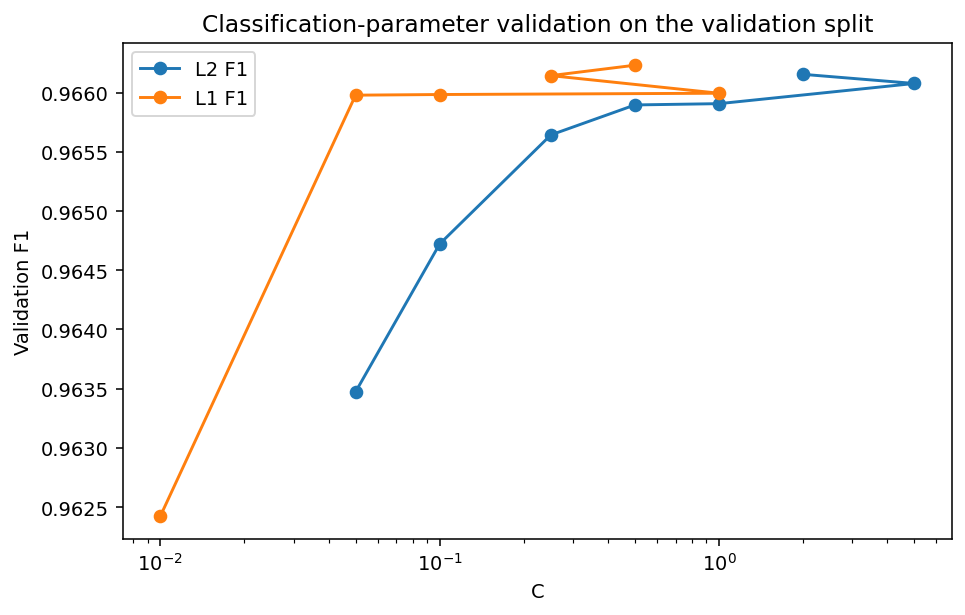

In [23]:
def build_lr_pipeline_for_validation(X: pd.DataFrame, *, penalty: str = "l2", C: float = 1.0) -> Pipeline:
    numeric_columns = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_columns = [c for c in X.columns if c not in numeric_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )

    model = LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        penalty=penalty,
        C=C,
        random_state=42,
    )

    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])


def evaluate_validation_metrics(y_true: pd.Series, probabilities: np.ndarray, threshold: float = 0.50) -> dict:
    preds = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, preds)),
        "precision": float(precision_score(y_true, preds, zero_division=0)),
        "recall": float(recall_score(y_true, preds, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, preds, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, probabilities)),
        "pr_auc": float(average_precision_score(y_true, probabilities)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def coefficient_table_from_pipeline(pipe: Pipeline) -> pd.DataFrame:
    feature_names = pipe.named_steps["preprocessor"].get_feature_names_out()
    coefficients = pipe.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "abs_coefficient": np.abs(coefficients),
        }
    ).sort_values("abs_coefficient", ascending=False)
    return coef_df.reset_index(drop=True)


validation_bundle = feature_bundles["engineered_full_lr"]
X_train, X_val, X_test, y_train, y_val, y_test = split_data(validation_bundle.X, validation_bundle.y, random_state=42)

l2_rows = []
for C in [0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00]:
    pipe = build_lr_pipeline_for_validation(validation_bundle.X, penalty="l2", C=C)
    pipe.fit(X_train, y_train)
    val_prob = pipe.predict_proba(X_val)[:, 1]
    metrics = evaluate_validation_metrics(y_val, val_prob, threshold=0.50)
    metrics.update({"penalty": "l2", "C": C})
    l2_rows.append(metrics)

l2_validation = (
    pd.DataFrame(l2_rows)
    .sort_values(["f1", "roc_auc", "precision"], ascending=False)
    .reset_index(drop=True)
)

l1_rows = []
l1_feature_sets = {}
for C in [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]:
    pipe = build_lr_pipeline_for_validation(validation_bundle.X, penalty="l1", C=C)
    pipe.fit(X_train, y_train)
    val_prob = pipe.predict_proba(X_val)[:, 1]
    metrics = evaluate_validation_metrics(y_val, val_prob, threshold=0.50)
    coef_df = coefficient_table_from_pipeline(pipe)
    selected_df = coef_df[coef_df["abs_coefficient"] > 1e-8].copy().reset_index(drop=True)
    l1_feature_sets[C] = selected_df
    metrics.update(
        {
            "penalty": "l1",
            "C": C,
            "selected_transformed_features": int(len(selected_df)),
        }
    )
    l1_rows.append(metrics)

l1_validation = (
    pd.DataFrame(l1_rows)
    .sort_values(["f1", "roc_auc", "precision"], ascending=False)
    .reset_index(drop=True)
)

best_l2_row = l2_validation.iloc[0]
best_sparse_row = l1_validation.iloc[0]
best_sparse_features = l1_feature_sets[float(best_sparse_row["C"])].copy()

display(Markdown("#### L2 Logistic Regression validation sweep"))
display(l2_validation.round(4))

display(Markdown("#### L1 sparse Logistic Regression validation sweep (formal feature-selection check)"))
display(l1_validation.round(4))

display(Markdown(
    f"#### Best sparse model selected **{int(best_sparse_row['selected_transformed_features'])}** transformed features "
    f"at **C = {best_sparse_row['C']:.2f}**"
))
display(best_sparse_features.head(25).round(4))

l2_validation.to_csv(OUTPUT_DIR / "validation_l2_hyperparameter_sweep.csv", index=False)
l1_validation.to_csv(OUTPUT_DIR / "validation_l1_sparse_sweep.csv", index=False)
best_sparse_features.to_csv(OUTPUT_DIR / "validation_l1_selected_features.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(l2_validation["C"], l2_validation["f1"], marker="o", label="L2 F1")
ax.plot(l1_validation["C"], l1_validation["f1"], marker="o", label="L1 F1")
ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("Validation F1")
ax.set_title("Classification-parameter validation on the validation split")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_parameter_sweep_f1.png", bbox_inches="tight")
plt.show()

### 9.3) Recursive Feature Elimination (RFE) across all feature bundles

This stricter feature-selection section now applies RFE to **all three feature bundles** instead of only the engineered-full feature set:

1. `baseline_cleaned_lr`
2. `engineered_full_lr`
3. `leakage_aware_lr`

RFE is useful here because it uses Logistic Regression itself to repeatedly remove the weakest transformed features after imputation, scaling, and one-hot encoding.
The comparison is made at two levels:

- the best selected-feature count **within each bundle**
- the overall best RFE-supported bundle across all three bundles

The selected-feature counts are **transformed features**, not raw columns, because categorical variables are expanded by one-hot encoding.

When the original dirty CSV is available and the notebook is run end-to-end, this cell saves:

- `validation_rfe_feature_selection_all_bundles.csv`
- `validation_rfe_best_by_bundle.csv`
- `validation_rfe_overall_best_bundle.csv`
- `validation_rfe_selected_features_by_bundle.csv`
- `validation_rfe_selected_features.csv` as a compatibility alias for the overall best selected-feature table


In [24]:
from sklearn.feature_selection import RFE


def build_rfe_lr_pipeline(X: pd.DataFrame, n_features_to_select: int, *, C: float = 1.0) -> Pipeline:
    """Build an impute/scale/encode -> RFE -> Logistic Regression pipeline."""
    numeric_columns = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_columns = [c for c in X.columns if c not in numeric_columns]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )

    rfe_estimator = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        penalty="l2",
        C=C,
        random_state=42,
    )

    selector = RFE(
        estimator=rfe_estimator,
        n_features_to_select=int(n_features_to_select),
        step=0.20,
    )

    final_model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="liblinear",
        penalty="l2",
        C=C,
        random_state=42,
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("selector", selector),
            ("model", final_model),
        ]
    )


rfe_requested_counts = [5, 10, 15, 20, 25, 30, 40, 50]
rfe_rows = []
rfe_selected_feature_rows = []
rfe_threshold_rows = []
rfe_feature_sets = {}

rfe_bundle_reason = {
    "baseline_cleaned_lr": (
        "This would mean the cleaned original columns already contain most of the useful signal, "
        "so extra engineered variables add little validation benefit."
    ),
    "engineered_full_lr": (
        "This means the proposal-driven temporal, usage-intensity, and condition features add useful predictive signal "
        "while retaining the strongest condition indicators."
    ),
    "leakage_aware_lr": (
        "This would mean the reduced feature set gives the best validation trade-off while avoiding condition-heavy variables "
        "that may inflate apparent performance."
    ),
}

for bundle_name, bundle in feature_bundles.items():
    X_train_rfe, X_val_rfe, X_test_rfe, y_train_rfe, y_val_rfe, y_test_rfe = split_data(
        bundle.X,
        bundle.y,
        random_state=42,
    )

    # Count transformed features after the same preprocessing used by Logistic Regression.
    rfe_probe_preprocessor = build_lr_pipeline_for_validation(bundle.X, penalty="l2", C=1.0).named_steps[
        "preprocessor"
    ]
    rfe_probe_preprocessor.fit(X_train_rfe, y_train_rfe)
    rfe_all_feature_names = rfe_probe_preprocessor.get_feature_names_out()
    rfe_total_transformed_features = len(rfe_all_feature_names)

    # Evaluate several subset sizes and include the all-feature case as a no-elimination reference.
    rfe_feature_counts = sorted(
        {
            int(min(count, rfe_total_transformed_features))
            for count in rfe_requested_counts
            if count <= rfe_total_transformed_features
        }
    )
    if rfe_total_transformed_features not in rfe_feature_counts:
        rfe_feature_counts.append(int(rfe_total_transformed_features))
    if not rfe_feature_counts:
        rfe_feature_counts = [int(rfe_total_transformed_features)]

    for selected_count in rfe_feature_counts:
        rfe_pipe = build_rfe_lr_pipeline(bundle.X, selected_count, C=1.0)
        rfe_pipe.fit(X_train_rfe, y_train_rfe)

        rfe_val_prob = rfe_pipe.predict_proba(X_val_rfe)[:, 1]
        best_rfe_threshold, rfe_threshold_table = search_threshold(y_val_rfe, rfe_val_prob)
        rfe_metrics = evaluate_validation_metrics(
            y_val_rfe,
            rfe_val_prob,
            threshold=best_rfe_threshold.threshold,
        )

        transformed_feature_names = rfe_pipe.named_steps["preprocessor"].get_feature_names_out()
        selected_mask = rfe_pipe.named_steps["selector"].support_
        selected_feature_names = transformed_feature_names[selected_mask]
        selected_coefficients = rfe_pipe.named_steps["model"].coef_[0]

        selected_features_df = (
            pd.DataFrame(
                {
                    "bundle": bundle_name,
                    "selected_transformed_features": int(selected_count),
                    "total_transformed_features": int(rfe_total_transformed_features),
                    "feature": selected_feature_names,
                    "coefficient": selected_coefficients,
                    "abs_coefficient": np.abs(selected_coefficients),
                }
            )
            .sort_values("abs_coefficient", ascending=False)
            .reset_index(drop=True)
        )
        selected_features_df.insert(3, "feature_rank_within_candidate", np.arange(1, len(selected_features_df) + 1))

        rfe_feature_sets[(bundle_name, int(selected_count))] = selected_features_df
        rfe_selected_feature_rows.append(selected_features_df)

        rfe_threshold_table = rfe_threshold_table.copy()
        rfe_threshold_table.insert(0, "bundle", bundle_name)
        rfe_threshold_table.insert(1, "selected_transformed_features", int(selected_count))
        rfe_threshold_rows.append(rfe_threshold_table)

        rfe_metrics.update(
            {
                "bundle": bundle_name,
                "selected_transformed_features": int(selected_count),
                "total_transformed_features": int(rfe_total_transformed_features),
                "feature_fraction": float(selected_count / rfe_total_transformed_features),
                "raw_input_features": int(bundle.X.shape[1]),
            }
        )
        rfe_rows.append(rfe_metrics)

rfe_validation = (
    pd.DataFrame(rfe_rows)
    .sort_values(
        ["f1", "roc_auc", "precision", "recall", "selected_transformed_features"],
        ascending=[False, False, False, False, True],
    )
    .reset_index(drop=True)
)

rfe_best_by_bundle = (
    rfe_validation
    .sort_values(
        ["bundle", "f1", "roc_auc", "precision", "recall", "selected_transformed_features"],
        ascending=[True, False, False, False, False, True],
    )
    .groupby("bundle", as_index=False, sort=False)
    .head(1)
    .sort_values(
        ["f1", "roc_auc", "precision", "recall", "selected_transformed_features"],
        ascending=[False, False, False, False, True],
    )
    .reset_index(drop=True)
)
rfe_best_by_bundle.insert(0, "bundle_rank", np.arange(1, len(rfe_best_by_bundle) + 1))

best_rfe_row = rfe_best_by_bundle.iloc[0]
best_rfe_bundle = str(best_rfe_row["bundle"])
best_rfe_feature_count = int(best_rfe_row["selected_transformed_features"])
best_rfe_features = rfe_feature_sets[(best_rfe_bundle, best_rfe_feature_count)].copy()

rfe_selected_features_all = pd.concat(rfe_selected_feature_rows, ignore_index=True)
rfe_thresholds_all = pd.concat(rfe_threshold_rows, ignore_index=True)

rfe_overall_best_bundle = pd.DataFrame(
    [
        {
            "best_bundle": best_rfe_bundle,
            "selected_transformed_features": best_rfe_feature_count,
            "total_transformed_features": int(best_rfe_row["total_transformed_features"]),
            "threshold": float(best_rfe_row["threshold"]),
            "accuracy": float(best_rfe_row["accuracy"]),
            "precision": float(best_rfe_row["precision"]),
            "recall": float(best_rfe_row["recall"]),
            "specificity": float(best_rfe_row["specificity"]),
            "f1": float(best_rfe_row["f1"]),
            "roc_auc": float(best_rfe_row["roc_auc"]),
            "pr_auc": float(best_rfe_row["pr_auc"]),
            "reason": rfe_bundle_reason.get(best_rfe_bundle, "Selected by the highest validation F1, with ROC-AUC as a tie-breaker."),
        }
    ]
)

rfe_display_columns = [
    "bundle",
    "selected_transformed_features",
    "total_transformed_features",
    "feature_fraction",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
    "pr_auc",
    "tn",
    "fp",
    "fn",
    "tp",
]

display(Markdown("#### RFE validation table across all three feature bundles"))
display(rfe_validation[rfe_display_columns].round(4))

display(Markdown("#### Best RFE result within each feature bundle"))
display(rfe_best_by_bundle[["bundle_rank"] + rfe_display_columns].round(4))

display(Markdown(
    f"#### Overall best RFE-supported bundle: **{best_rfe_bundle}**\n\n"
    f"It selected **{best_rfe_feature_count}** of "
    f"**{int(best_rfe_row['total_transformed_features'])}** transformed features, "
    f"with validation F1 = **{best_rfe_row['f1']:.4f}** and "
    f"ROC-AUC = **{best_rfe_row['roc_auc']:.4f}**.\n\n"
    f"**Why this bundle is best:** {rfe_bundle_reason.get(best_rfe_bundle, 'Selected by highest validation F1, with ROC-AUC as a tie-breaker.')}"
))
display(best_rfe_features.head(25).round(4))

# New all-bundle outputs.
rfe_validation.to_csv(OUTPUT_DIR / "validation_rfe_feature_selection_all_bundles.csv", index=False)
rfe_best_by_bundle.to_csv(OUTPUT_DIR / "validation_rfe_best_by_bundle.csv", index=False)
rfe_overall_best_bundle.to_csv(OUTPUT_DIR / "validation_rfe_overall_best_bundle.csv", index=False)
rfe_selected_features_all.to_csv(OUTPUT_DIR / "validation_rfe_selected_features_by_bundle.csv", index=False)
rfe_thresholds_all.to_csv(OUTPUT_DIR / "validation_rfe_thresholds_by_bundle.csv", index=False)

# Compatibility aliases used by the previous patch.
rfe_validation.to_csv(OUTPUT_DIR / "validation_rfe_feature_selection.csv", index=False)
best_rfe_features.to_csv(OUTPUT_DIR / "validation_rfe_selected_features.csv", index=False)


#### RFE validation table across all three feature bundles

,bundle,selected_transformed_features,total_transformed_features,feature_fraction,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,engineered_full_lr,10,44,0.2273,0.500,0.9606,0.9976,0.9537,0.9901,0.9751,0.9745,0.9945,1502,15,299,6156
1,baseline_cleaned_lr,15,38,0.3947,0.310,0.9586,0.9862,0.9624,0.9426,0.9741,0.9797,0.9956,1430,87,243,6212
2,engineered_full_lr,15,44,0.3409,0.315,0.9585,0.9863,0.9620,0.9433,0.9740,0.9797,0.9956,1431,86,245,6210
3,engineered_full_lr,30,44,0.6818,0.335,0.9546,0.9872,0.9563,0.9473,0.9715,0.9828,0.9961,1437,80,282,6173
4,baseline_cleaned_lr,30,38,0.7895,0.325,0.9543,0.9860,0.9572,0.9420,0.9714,0.9828,0.9961,1429,88,276,6179
5,engineered_full_lr,25,44,0.5682,0.330,0.9540,0.9863,0.9565,0.9433,0.9711,0.9828,0.9961,1431,86,281,6174
6,engineered_full_lr,20,44,0.4545,0.335,0.9540,0.9869,0.9558,0.9459,0.9711,0.9828,0.9961,1435,82,285,6170
7,baseline_cleaned_lr,25,38,0.6579,0.325,0.9538,0.9856,0.9569,0.9407,0.9711,0.9827,0.9961,1427,90,278,6177
8,baseline_cleaned_lr,38,38,1.0000,0.390,0.9541,0.9916,0.9514,0.9657,0.9711,0.9828,0.9961,1465,52,314,6141
9,baseline_cleaned_lr,20,38,0.5263,0.325,0.9537,0.9858,0.9566,0.9413,0.9710,0.9827,0.9961,1428,89,280,6175


#### Best RFE result within each feature bundle

,bundle_rank,bundle,selected_transformed_features,total_transformed_features,feature_fraction,threshold,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,1,engineered_full_lr,10,44,0.2273,0.50,0.9606,0.9976,0.9537,0.9901,0.9751,0.9745,0.9945,1502,15,299,6156
1,2,baseline_cleaned_lr,15,38,0.3947,0.31,0.9586,0.9862,0.9624,0.9426,0.9741,0.9797,0.9956,1430,87,243,6212
2,3,leakage_aware_lr,10,34,0.2941,0.20,0.7899,0.8432,0.9097,0.2802,0.8752,0.8206,0.9547,425,1092,583,5872


#### Overall best RFE-supported bundle: **engineered_full_lr**

It selected **10** of **44** transformed features, with validation F1 = **0.9751** and ROC-AUC = **0.9745**.

**Why this bundle is best:** This means the proposal-driven temporal, usage-intensity, and condition features add useful predictive signal while retaining the strongest condition indicators.

,bundle,selected_transformed_features,total_transformed_features,feature_rank_within_candidate,feature,coefficient,abs_coefficient
0,engineered_full_lr,10,44,1,cat__Battery_Status_Weak,6.0400,6.0400
1,engineered_full_lr,10,44,2,cat__Brake_Condition_Worn Out,5.9632,5.9632
2,engineered_full_lr,10,44,3,num__condition_score,3.5692,3.5692
3,engineered_full_lr,10,44,4,num__Reported_Issues,3.2834,3.2834
4,engineered_full_lr,10,44,5,cat__Brake_Condition_Good,-2.5951,2.5951
5,engineered_full_lr,10,44,6,cat__Tire_Condition_New,2.5432,2.5432
6,engineered_full_lr,10,44,7,cat__Battery_Status_Good,-2.4743,2.4743
7,engineered_full_lr,10,44,8,cat__Tire_Condition_Worn Out,-2.4651,2.4651
8,engineered_full_lr,10,44,9,cat__Maintenance_History_Poor,1.7048,1.7048
9,engineered_full_lr,10,44,10,cat__Maintenance_History_Good,-1.6602,1.6602


### 9.4) Full GridSearchCV validation for strict classification-parameter review

This extra cell is added for a stricter reviewer. It performs a formal `GridSearchCV` over valid Logistic Regression combinations across:

- `solver`
- `penalty`
- `C`
- `class_weight`

It uses stratified 3-fold cross-validation on the training split, refits the best model by F1-score, then evaluates the best estimator on the validation split using the same threshold-search logic already used in the notebook.

When the original dirty CSV is available and the notebook is run end-to-end, this cell saves:

- `validation_gridsearch_parameter_grid_candidates.csv`
- `validation_gridsearch_logreg.csv`
- `validation_gridsearch_best_validation_metrics.csv`
- `validation_gridsearch_thresholds.csv`


In [25]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV, ParameterGrid, StratifiedKFold


grid_search_C_values = [0.05, 0.10, 0.25, 0.50, 1.00, 2.00, 5.00]

# Keep only solver/penalty combinations that LogisticRegression supports.
grid_search_param_grid = [
    {
        "model__solver": ["liblinear"],
        "model__penalty": ["l1", "l2"],
        "model__C": grid_search_C_values,
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["lbfgs"],
        "model__penalty": ["l2"],
        "model__C": grid_search_C_values,
        "model__class_weight": [None, "balanced"],
    },
    {
        "model__solver": ["saga"],
        "model__penalty": ["l1", "l2"],
        "model__C": grid_search_C_values,
        "model__class_weight": [None, "balanced"],
    },
]

grid_search_candidates = pd.DataFrame(list(ParameterGrid(grid_search_param_grid)))
grid_search_candidates = grid_search_candidates.rename(
    columns={
        "model__solver": "solver",
        "model__penalty": "penalty",
        "model__C": "C",
        "model__class_weight": "class_weight",
    }
)
grid_search_candidates["class_weight"] = grid_search_candidates["class_weight"].fillna("None")

display(Markdown("#### GridSearchCV candidate parameter combinations"))
display(grid_search_candidates)
grid_search_candidates.to_csv(OUTPUT_DIR / "validation_gridsearch_parameter_grid_candidates.csv", index=False)

grid_search_base_pipeline = build_lr_pipeline_for_validation(validation_bundle.X, penalty="l2", C=1.0)
grid_search_base_pipeline.named_steps["model"].set_params(max_iter=5000)

grid_search_scoring = {
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "roc_auc": "roc_auc",
}

grid_search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

logreg_grid_search = GridSearchCV(
    estimator=grid_search_base_pipeline,
    param_grid=grid_search_param_grid,
    scoring=grid_search_scoring,
    refit="f1",
    cv=grid_search_cv,
    n_jobs=-1,
    return_train_score=False,
    error_score=np.nan,
)

logreg_grid_search.fit(X_train, y_train)

grid_results = pd.DataFrame(logreg_grid_search.cv_results_)
grid_results = grid_results[
    [
        "rank_test_f1",
        "mean_test_f1",
        "std_test_f1",
        "mean_test_precision",
        "mean_test_recall",
        "mean_test_roc_auc",
        "param_model__solver",
        "param_model__penalty",
        "param_model__C",
        "param_model__class_weight",
    ]
].rename(
    columns={
        "rank_test_f1": "rank_f1",
        "mean_test_f1": "cv_mean_f1",
        "std_test_f1": "cv_std_f1",
        "mean_test_precision": "cv_mean_precision",
        "mean_test_recall": "cv_mean_recall",
        "mean_test_roc_auc": "cv_mean_roc_auc",
        "param_model__solver": "solver",
        "param_model__penalty": "penalty",
        "param_model__C": "C",
        "param_model__class_weight": "class_weight",
    }
)
grid_results["class_weight"] = grid_results["class_weight"].fillna("None")
grid_results = grid_results.sort_values(["rank_f1", "cv_mean_roc_auc"]).reset_index(drop=True)

best_grid_estimator = logreg_grid_search.best_estimator_
grid_val_prob = best_grid_estimator.predict_proba(X_val)[:, 1]
best_grid_threshold, grid_threshold_table = search_threshold(y_val, grid_val_prob)
best_grid_metrics = evaluate_validation_metrics(y_val, grid_val_prob, threshold=best_grid_threshold.threshold)

best_grid_summary = pd.DataFrame(
    [
        {
            "solver": logreg_grid_search.best_params_["model__solver"],
            "penalty": logreg_grid_search.best_params_["model__penalty"],
            "C": logreg_grid_search.best_params_["model__C"],
            "class_weight": "None"
            if logreg_grid_search.best_params_["model__class_weight"] is None
            else logreg_grid_search.best_params_["model__class_weight"],
            "cv_best_f1": logreg_grid_search.best_score_,
            "validation_threshold": best_grid_metrics["threshold"],
            "validation_accuracy": best_grid_metrics["accuracy"],
            "validation_precision": best_grid_metrics["precision"],
            "validation_recall": best_grid_metrics["recall"],
            "validation_specificity": best_grid_metrics["specificity"],
            "validation_f1": best_grid_metrics["f1"],
            "validation_roc_auc": best_grid_metrics["roc_auc"],
            "validation_pr_auc": best_grid_metrics["pr_auc"],
            "validation_tn": best_grid_metrics["tn"],
            "validation_fp": best_grid_metrics["fp"],
            "validation_fn": best_grid_metrics["fn"],
            "validation_tp": best_grid_metrics["tp"],
        }
    ]
)
best_grid_row = best_grid_summary.iloc[0]

display(Markdown("#### Full GridSearchCV results, sorted by cross-validated F1"))
display(grid_results.head(20).round(4))

display(Markdown("#### Best GridSearchCV model validated on the validation split"))
display(best_grid_summary.round(4))

grid_results.to_csv(OUTPUT_DIR / "validation_gridsearch_logreg.csv", index=False)
best_grid_summary.to_csv(OUTPUT_DIR / "validation_gridsearch_best_validation_metrics.csv", index=False)
grid_threshold_table.to_csv(OUTPUT_DIR / "validation_gridsearch_thresholds.csv", index=False)


#### GridSearchCV candidate parameter combinations

,C,class_weight,penalty,solver
0,0.05,None,l1,liblinear
1,0.05,None,l2,liblinear
2,0.05,balanced,l1,liblinear
3,0.05,balanced,l2,liblinear
4,0.10,None,l1,liblinear
...,...,...,...,...
65,2.00,balanced,l2,saga
66,5.00,None,l1,saga
67,5.00,None,l2,saga
68,5.00,balanced,l1,saga


#### Full GridSearchCV results, sorted by cross-validated F1

,rank_f1,cv_mean_f1,cv_std_f1,cv_mean_precision,cv_mean_recall,cv_mean_roc_auc,solver,penalty,C,class_weight
0,1,0.9676,0.0012,0.9667,0.9684,0.9852,saga,l1,5.00,None
1,2,0.9675,0.0012,0.9667,0.9684,0.9852,liblinear,l1,5.00,None
2,3,0.9675,0.0012,0.9666,0.9684,0.9852,liblinear,l1,2.00,None
3,4,0.9675,0.0013,0.9661,0.9689,0.9849,liblinear,l2,1.00,None
4,4,0.9675,0.0013,0.9661,0.9689,0.9849,saga,l2,1.00,None
5,6,0.9675,0.0015,0.9661,0.9689,0.9849,lbfgs,l2,1.00,None
6,7,0.9675,0.0013,0.9664,0.9685,0.9851,liblinear,l2,5.00,None
7,8,0.9675,0.0012,0.9665,0.9685,0.9851,saga,l1,2.00,None
8,9,0.9674,0.0014,0.9663,0.9686,0.9850,liblinear,l2,2.00,None
9,10,0.9674,0.0013,0.9664,0.9685,0.9851,saga,l2,5.00,None


#### Best GridSearchCV model validated on the validation split

,solver,penalty,C,class_weight,cv_best_f1,validation_threshold,validation_accuracy,validation_precision,validation_recall,validation_specificity,validation_f1,validation_roc_auc,validation_pr_auc,validation_tn,validation_fp,validation_fn,validation_tp
0,saga,l1,5.0,None,0.9676,0.625,0.9488,0.98,0.9563,0.9169,0.968,0.9836,0.9963,1391,126,282,6173


## 10) Metrics comparison
These are the main numeric results you usually show in the final report.

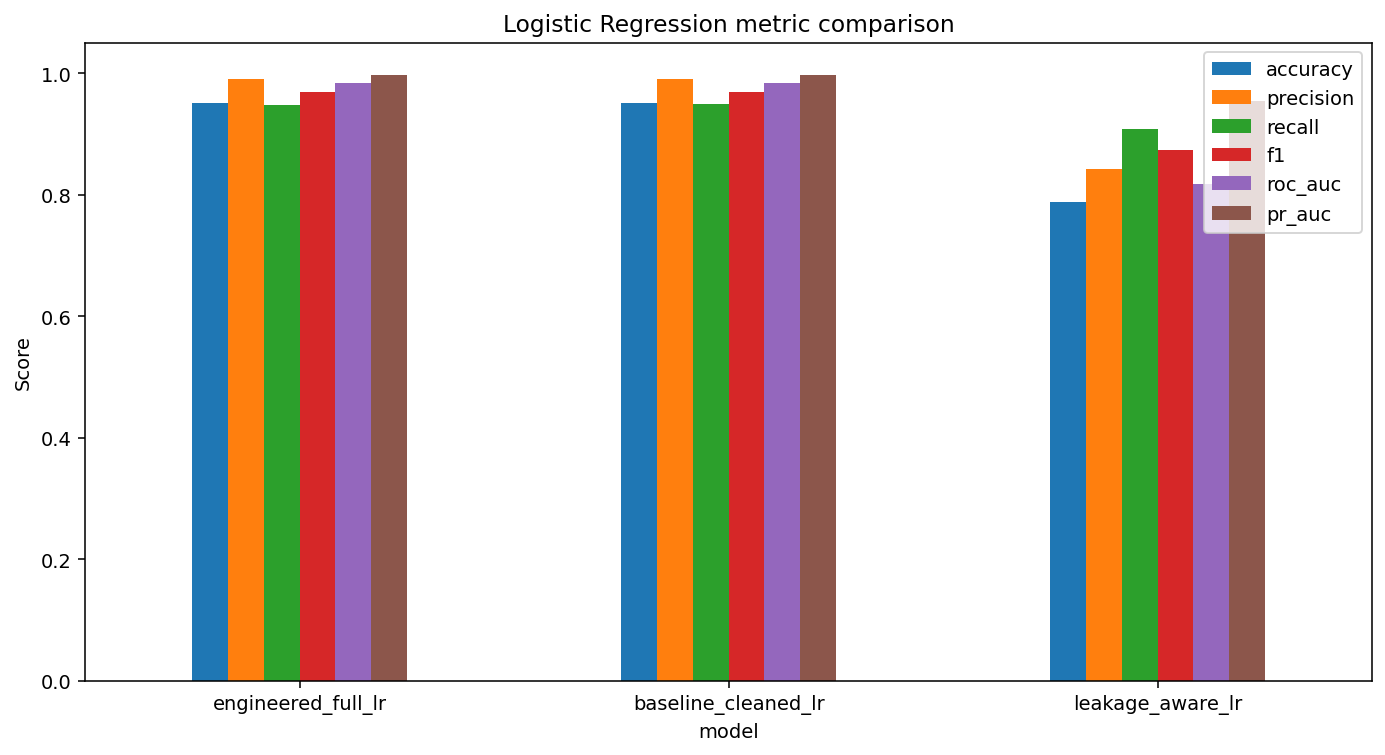

In [26]:
plot_metrics = model_summary.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_metrics.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Logistic Regression metric comparison")
ax.set_ylabel("Score")
ax.set_xticklabels(plot_metrics.index, rotation=0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "metric_comparison.png", bbox_inches="tight")
plt.show()

## 11) ROC curves

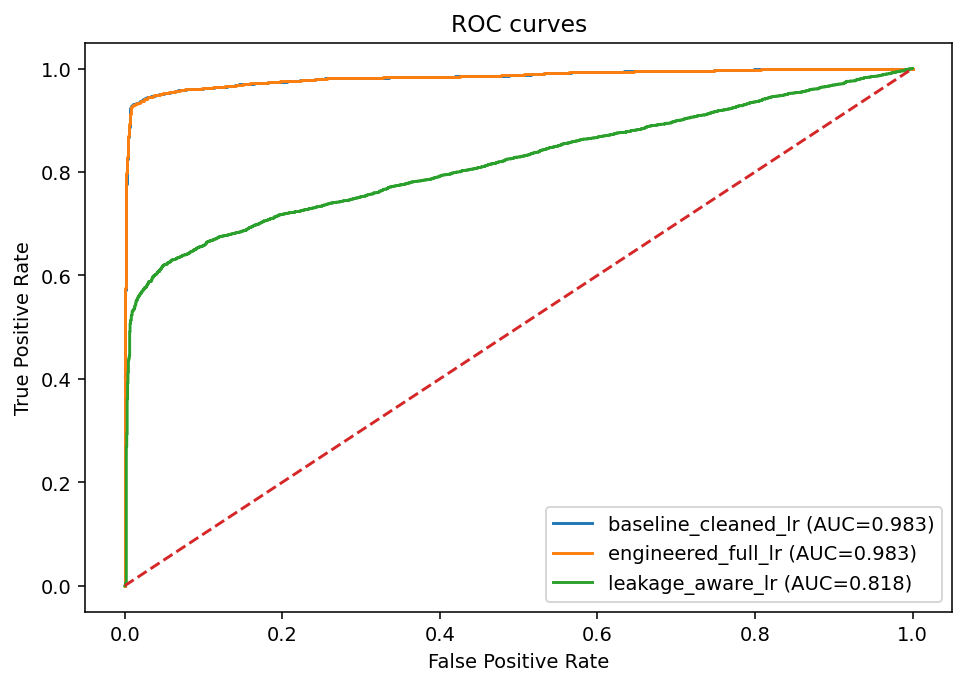

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results.items():
    ax.plot(res["fpr"], res["tpr"], label=f"{name} (AUC={res['tuned_metrics']['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curves")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_curves.png", bbox_inches="tight")
plt.show()

## 12) Precision-recall curves

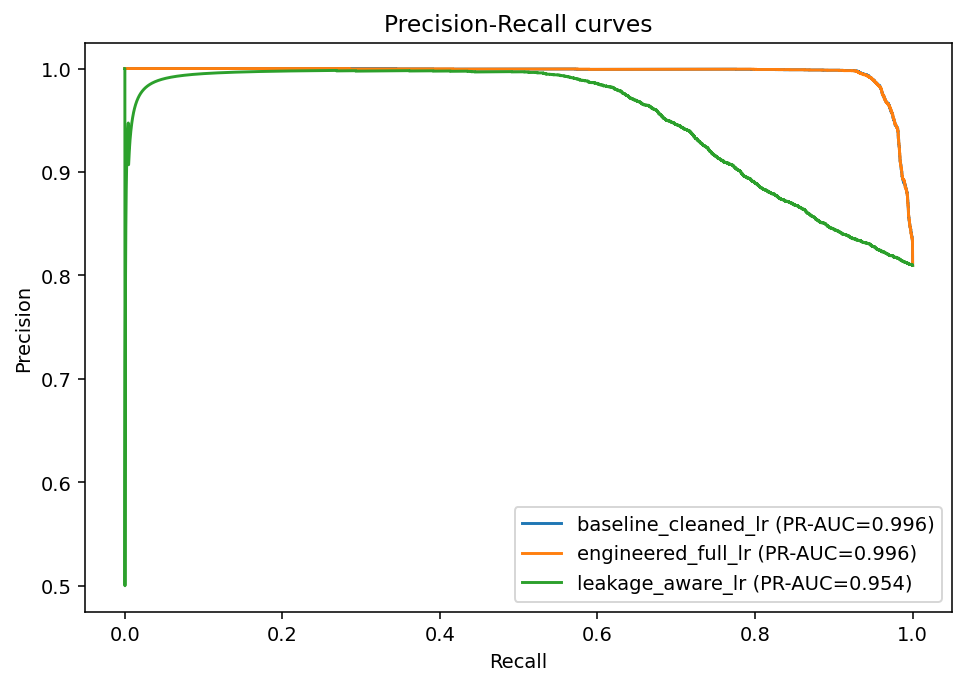

In [28]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, res in results.items():
    ax.plot(res["pr_recall"], res["pr_precision"], label=f"{name} (PR-AUC={res['tuned_metrics']['pr_auc']:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curves")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "precision_recall_curves.png", bbox_inches="tight")
plt.show()

## 13) Tuned-threshold confusion matrices

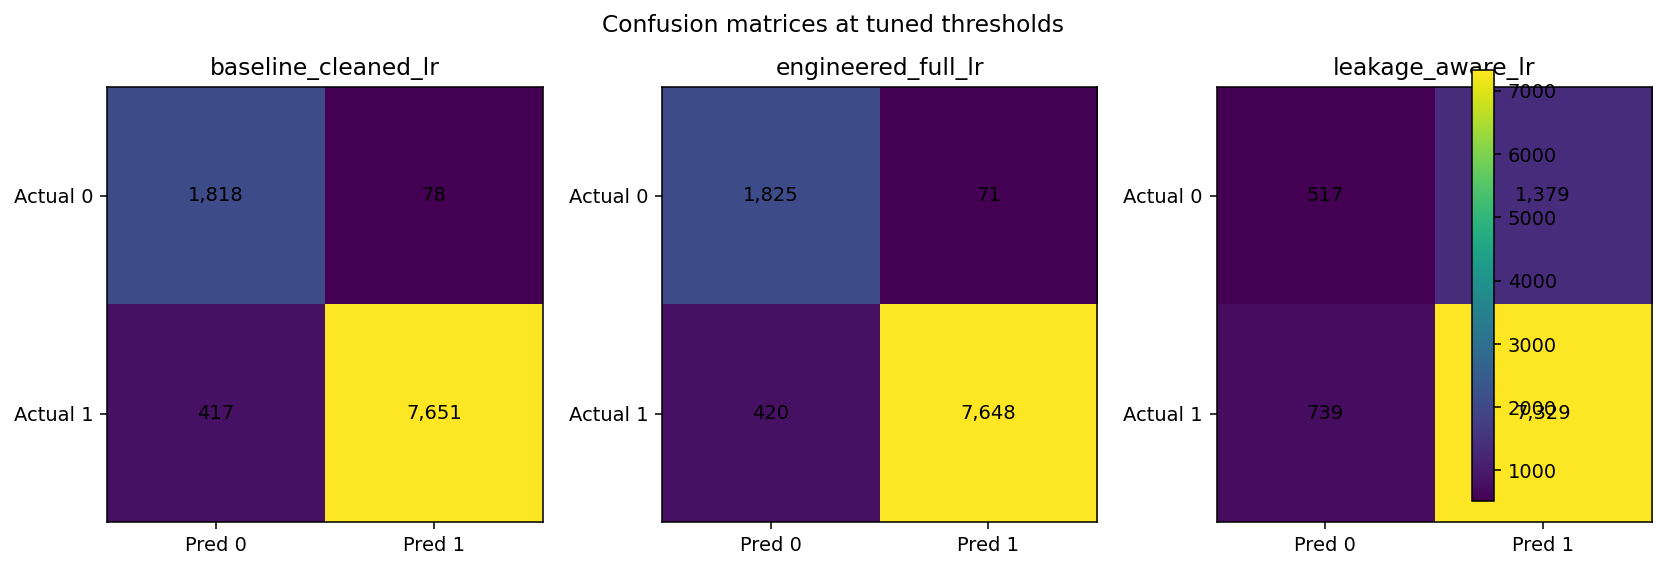

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, (name, res) in zip(axes, results.items()):
    m = res["tuned_metrics"]
    matrix = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    im = ax.imshow(matrix)
    ax.set_title(name)
    ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
    ax.set_yticks([0, 1], labels=["Actual 0", "Actual 1"])
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, f"{value:,}", ha="center", va="center")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.04)
fig.suptitle("Confusion matrices at tuned thresholds")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrices.png", bbox_inches="tight")
plt.show()

## 14) Most influential logistic coefficients
The coefficient plots help explain **why** Logistic Regression predicts higher or lower maintenance risk.

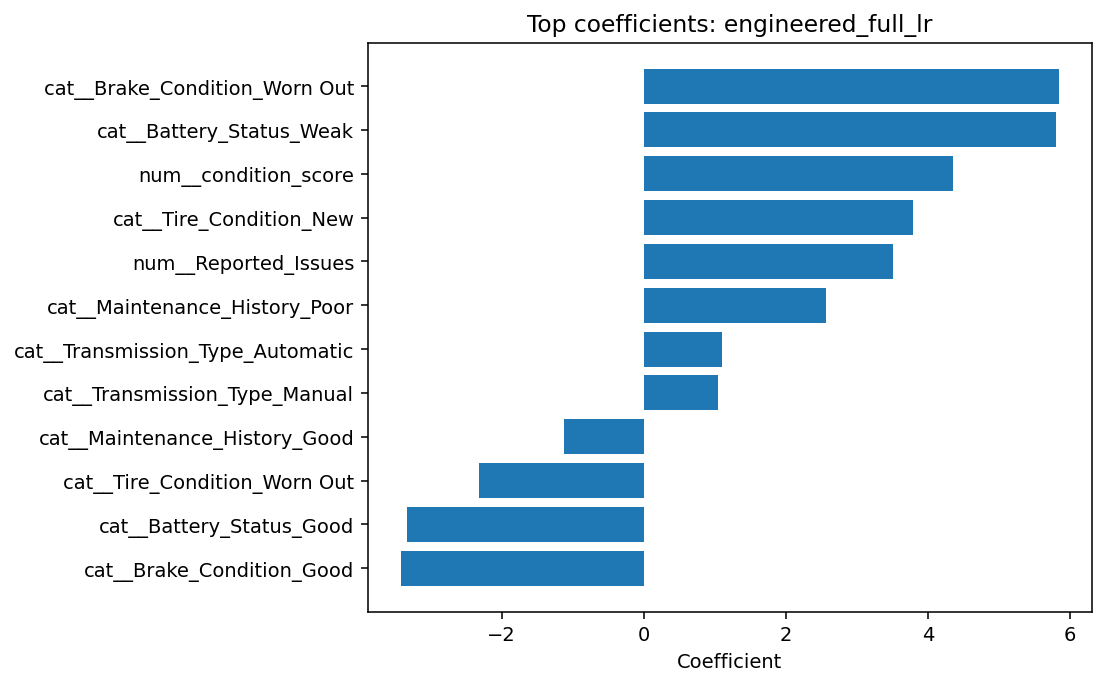

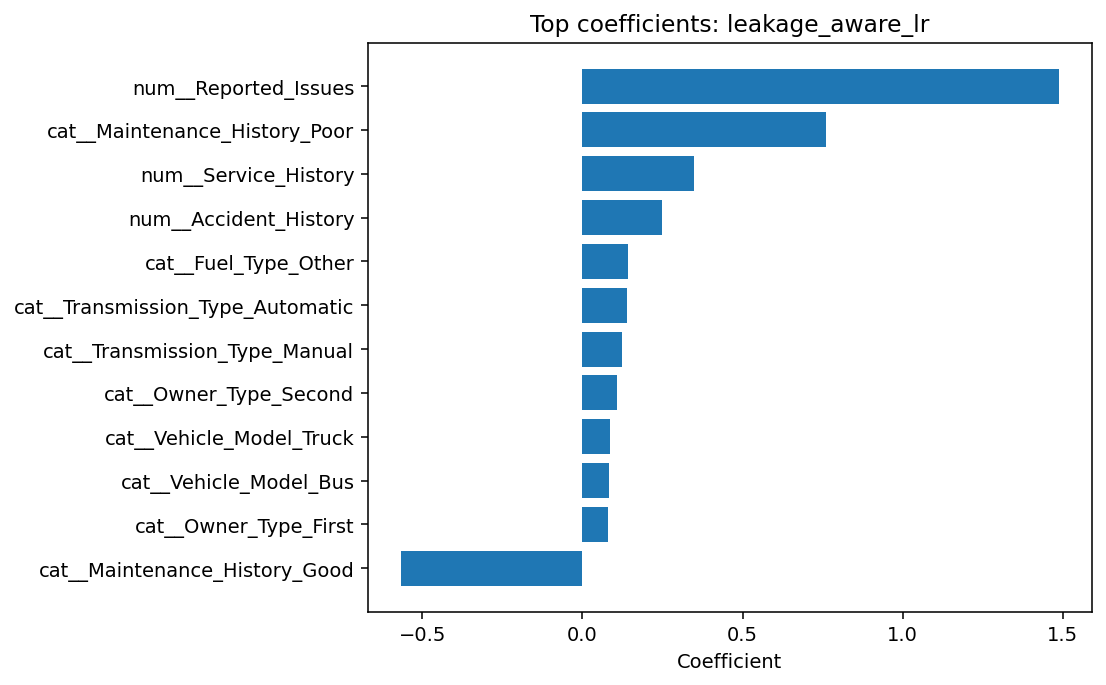

In [30]:
def plot_top_coefficients(coef_df: pd.DataFrame, title: str, save_name: str, top_n: int = 12):
    plot_df = coef_df.head(top_n).sort_values("coefficient")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(plot_df["feature"], plot_df["coefficient"])
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / save_name, bbox_inches="tight")
    plt.show()

plot_top_coefficients(results["engineered_full_lr"]["coefficients"], "Top coefficients: engineered_full_lr", "top_coefficients_engineered_full.png")
plot_top_coefficients(results["leakage_aware_lr"]["coefficients"], "Top coefficients: leakage_aware_lr", "top_coefficients_leakage_aware.png")

## 15) Risk-band output and per-row maintenance priority
The proposal asked for probability-based output that can be translated into **Low / Medium / High** maintenance priority instead of using only a hard yes/no decision.

This section now produces two outputs:

1. the original **risk-band summary** table, which counts vehicles in Low / Medium / High bands; and
2. a new **row-level engineered_full_lr maintenance-priority table**, where every row in the cleaned modeling dataset receives:
   - predicted maintenance probability
   - Low / Medium / High `maintenance_priority`
   - tuned yes/no prediction using the engineered-full Logistic Regression threshold
   - train / validation / test split marker

The row-level table is saved as `engineered_full_maintenance_priority_by_row.csv`.


#### Held-out test-set risk-band summary for all model variants

,model,band,vehicles,avg_probability,actual_positive_rate
0,baseline_cleaned_lr,Low,2250,0.0809,0.1889
1,baseline_cleaned_lr,Medium,476,0.5614,0.8761
2,baseline_cleaned_lr,High,7238,0.9815,0.9983
3,engineered_full_lr,Low,2253,0.0804,0.1891
4,engineered_full_lr,Medium,457,0.5611,0.8753
5,engineered_full_lr,High,7254,0.9816,0.9983
6,leakage_aware_lr,Low,2953,0.2248,0.5957
7,leakage_aware_lr,Medium,2421,0.5528,0.7253
8,leakage_aware_lr,High,4590,0.8677,0.9919


#### Held-out test-set risk-band summary for engineered_full_lr

,model,band,vehicles,avg_probability,actual_positive_rate
0,engineered_full_lr,Low,2253,0.0804,0.1891
1,engineered_full_lr,Medium,457,0.5611,0.8753
2,engineered_full_lr,High,7254,0.9816,0.9983


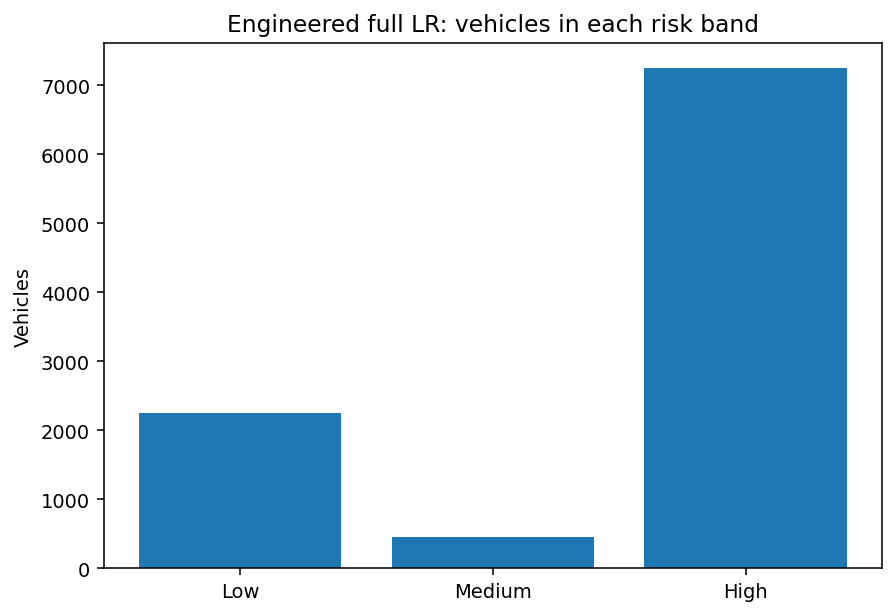

#### Engineered_full_lr maintenance priority preview: top 20 highest-probability rows

,dataset_row_id,data_split,engineered_full_lr_probability,maintenance_priority,engineered_full_lr_predicted_need_maintenance,actual_need_maintenance,Vehicle_Model,Vehicle_Age,Mileage,Reported_Issues,Service_History,Accident_History,days_since_last_service,days_to_warranty_expiry,condition_score
0,710,train,1.0,High,1,1,Car,5.0,59848.000,8.0,6.0,3.0,350.0,-187.0,6.0
1,14726,train,1.0,High,1,1,Bus,1.0,57692.000,8.0,8.0,2.0,613.0,-33.0,4.0
2,18363,train,1.0,High,1,1,Motorcycle,3.0,55885.000,8.0,7.0,0.0,525.0,1.0,4.0
3,19579,validation,1.0,High,1,1,Truck,8.0,51330.000,8.0,8.0,3.0,348.0,334.0,4.0
4,25914,test,1.0,High,1,1,Truck,6.0,35393.000,8.0,9.0,3.0,596.0,-110.0,5.0
5,30250,train,1.0,High,1,1,Car,2.0,39991.000,8.0,9.0,3.0,535.0,-55.0,4.0
6,26131,train,1.0,High,1,1,Motorcycle,9.0,59905.000,8.0,4.0,0.0,468.0,-187.0,5.0
7,31409,train,1.0,High,1,1,Van,8.0,77429.000,8.0,5.0,3.0,506.0,-139.0,5.0
8,31367,train,1.0,High,1,1,Motorcycle,2.0,72929.000,8.0,8.0,2.0,328.0,253.0,5.0
9,37235,test,1.0,High,1,1,Truck,4.0,38216.000,8.0,2.0,3.0,338.0,-17.0,6.0


#### Row-level maintenance-priority distribution

,maintenance_priority,vehicles,avg_probability,actual_positive_rate
0,Low,11179,0.0795,0.1797
1,Medium,2225,0.5551,0.8858
2,High,36416,0.9821,0.9985


Saved 49,820 row-level engineered_full_lr maintenance-priority predictions to c:\Users\Dell\Desktop\vehicle_maintenance_logreg_project\notebook_outputs\engineered_full_maintenance_priority_by_row.csv


In [31]:
# Keep the aggregate risk-band summary for all three model variants.
all_risk_bands = pd.concat([res["risk_bands"] for res in results.values()], ignore_index=True)
display(Markdown("#### Held-out test-set risk-band summary for all model variants"))
display(all_risk_bands.round(4))
all_risk_bands.to_csv(OUTPUT_DIR / "all_model_risk_bands_notebook.csv", index=False)

# Focus on engineered_full_lr because this was the best-performing deployed feature bundle.
full_risk = results["engineered_full_lr"]["risk_bands"].copy()
display(Markdown("#### Held-out test-set risk-band summary for engineered_full_lr"))
display(full_risk.round(4))
full_risk.to_csv(OUTPUT_DIR / "engineered_full_risk_band_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(full_risk["band"].astype(str), full_risk["vehicles"])
ax.set_title("Engineered full LR: vehicles in each risk band")
ax.set_ylabel("Vehicles")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "engineered_full_risk_bands.png", bbox_inches="tight")
plt.show()

# New requirement: score every row of the cleaned modeling dataset with engineered_full_lr
# and store the Low / Medium / High band as a row-level maintenance priority.
engineered_full_bundle = feature_bundles["engineered_full_lr"]
engineered_full_result = results["engineered_full_lr"]
engineered_full_pipeline = engineered_full_result["pipeline"]
engineered_full_threshold = engineered_full_result["threshold_info"].threshold

# Recreate the deterministic split used earlier so the row-level file shows whether a row was
# part of the train, validation, or test subset. This is for traceability only; the test-set
# metrics above remain the unbiased evaluation output.
X_train_full, X_val_full, X_test_full, y_train_full, y_val_full, y_test_full = split_data(
    engineered_full_bundle.X,
    engineered_full_bundle.y,
    random_state=42,
)

split_labels = pd.Series(index=engineered_full_bundle.X.index, dtype="object")
split_labels.loc[X_train_full.index] = "train"
split_labels.loc[X_val_full.index] = "validation"
split_labels.loc[X_test_full.index] = "test"

# Predict maintenance probability for every cleaned modeling row using the fitted engineered-full pipeline.
# This creates the practical priority output requested by the proposal.
row_probabilities = engineered_full_pipeline.predict_proba(engineered_full_bundle.X)[:, 1]
row_priority = engineered_df.loc[engineered_full_bundle.X.index].copy()

row_priority.insert(0, "dataset_row_id", np.arange(1, len(row_priority) + 1))
row_priority.insert(1, "data_split", split_labels.to_numpy())
row_priority.insert(2, "engineered_full_lr_probability", row_probabilities)
row_priority.insert(3, "maintenance_priority", pd.cut(row_probabilities, bins=RISK_BINS, labels=RISK_LABELS).astype(str))
row_priority.insert(4, "engineered_full_lr_threshold", engineered_full_threshold)
row_priority.insert(
    5,
    "engineered_full_lr_predicted_need_maintenance",
    (row_probabilities >= engineered_full_threshold).astype(int),
)
row_priority.insert(6, "actual_need_maintenance", engineered_full_bundle.y.astype(int).to_numpy())

# A compact preview is displayed in the notebook; the saved CSV contains all available cleaned/engineered columns.
priority_preview_columns = [
    "dataset_row_id",
    "data_split",
    "engineered_full_lr_probability",
    "maintenance_priority",
    "engineered_full_lr_predicted_need_maintenance",
    "actual_need_maintenance",
    "Vehicle_Model",
    "Vehicle_Age",
    "Mileage",
    "Reported_Issues",
    "Service_History",
    "Accident_History",
    "days_since_last_service",
    "days_to_warranty_expiry",
    "condition_score",
]
priority_preview_columns = [c for c in priority_preview_columns if c in row_priority.columns]

# Summary confirms that every cleaned modeling row received exactly one priority band.
row_priority_summary = (
    row_priority.groupby("maintenance_priority", observed=False)
    .agg(
        vehicles=("dataset_row_id", "size"),
        avg_probability=("engineered_full_lr_probability", "mean"),
        actual_positive_rate=("actual_need_maintenance", "mean"),
    )
    .reindex(RISK_LABELS)
    .reset_index()
)

row_priority_sorted = row_priority.sort_values(
    ["engineered_full_lr_probability", "dataset_row_id"],
    ascending=[False, True],
).reset_index(drop=True)

display(Markdown("#### Engineered_full_lr maintenance priority preview: top 20 highest-probability rows"))
display(row_priority_sorted[priority_preview_columns].head(20).round(4))

display(Markdown("#### Row-level maintenance-priority distribution"))
display(row_priority_summary.round(4))

row_priority.to_csv(OUTPUT_DIR / "engineered_full_maintenance_priority_by_row.csv", index=False)
row_priority_sorted.to_csv(OUTPUT_DIR / "engineered_full_maintenance_priority_ranked.csv", index=False)
row_priority_summary.to_csv(OUTPUT_DIR / "engineered_full_maintenance_priority_summary.csv", index=False)

print(
    f"Saved {len(row_priority):,} row-level engineered_full_lr maintenance-priority predictions to "
    f"{OUTPUT_DIR / 'engineered_full_maintenance_priority_by_row.csv'}"
)


## 16) Added Logistic Regression diagnostics requested

This section adds the extra Logistic Regression outputs you explicitly asked for:

1. **Model interpretation** using coefficients, odds ratios, 95% confidence intervals, and p-values.  
2. **Model performance metrics** in one clean table: confusion-matrix counts, accuracy, precision, recall (sensitivity), specificity, F1-score, ROC-AUC, PR-AUC, and Brier score.  
3. **Goodness-of-fit statistics** from a formal `statsmodels` Logit fit: Likelihood Ratio Chi-Square, McFadden pseudo-R², Cox-Snell pseudo-R², Nagelkerke pseudo-R², AIC, and BIC.

The predictive scores below still come from the earlier **scikit-learn pipeline** used for deployment-style evaluation.  
The inferential diagnostics below use a separate **statsmodels Logit** fit on the same training split and same cleaned / encoded feature space.

> **Important note for the full model:**  
> `condition_score` is an exact aggregate of `Tire_Condition`, `Brake_Condition`, and `Battery_Status`.  
> For the inferential `statsmodels` fit, the notebook temporarily drops `condition_score` when those three source variables are already present, so the design matrix stays full-rank and the goodness-of-fit statistics remain valid.


In [32]:
import scipy.sparse as sp
from scipy.stats import chi2
import statsmodels.api as sm


def build_inference_preprocessor(X: pd.DataFrame) -> ColumnTransformer:
    numeric_columns = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    categorical_columns = [c for c in X.columns if c not in numeric_columns]

    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_columns,
            ),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first")),
                    ]
                ),
                categorical_columns,
            ),
        ]
    )


def prepare_inference_features(X: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    X_infer = X.copy()
    dropped = []

    if {"Tire_Condition", "Brake_Condition", "Battery_Status", "condition_score"}.issubset(X_infer.columns):
        X_infer = X_infer.drop(columns=["condition_score"])
        dropped.append("condition_score")

    return X_infer, dropped


def prepare_statsmodels_design(bundle: FeatureBundle, random_state: int = 42):
    X_infer, dropped = prepare_inference_features(bundle.X)
    X_train, X_val, X_test, y_train, y_val, y_test = split_data(X_infer, bundle.y, random_state=random_state)

    infer_preprocessor = build_inference_preprocessor(X_infer)
    X_train_t = infer_preprocessor.fit_transform(X_train)
    X_test_t = infer_preprocessor.transform(X_test)

    if sp.issparse(X_train_t):
        X_train_t = X_train_t.toarray()
    if sp.issparse(X_test_t):
        X_test_t = X_test_t.toarray()

    feature_names = infer_preprocessor.get_feature_names_out()

    X_train_df = pd.DataFrame(X_train_t, columns=feature_names, index=X_train.index).astype(float)
    X_test_df = pd.DataFrame(X_test_t, columns=feature_names, index=X_test.index).astype(float)

    non_constant = X_train_df.nunique(dropna=False) > 1
    X_train_df = X_train_df.loc[:, non_constant]
    X_test_df = X_test_df.loc[:, X_train_df.columns]

    X_train_sm = sm.add_constant(X_train_df, has_constant="add")
    X_test_sm = sm.add_constant(X_test_df, has_constant="add")

    return {
        "dropped_for_inference": dropped,
        "preprocessor": infer_preprocessor,
        "X_train_sm": X_train_sm,
        "X_test_sm": X_test_sm,
        "y_train": y_train.astype(int),
        "y_test": y_test.astype(int),
    }


def fit_inference_logit(model_name: str, random_state: int = 42):
    bundle = feature_bundles[model_name]
    design = prepare_statsmodels_design(bundle, random_state=random_state)

    sm_model = sm.Logit(design["y_train"], design["X_train_sm"])
    try:
        sm_result = sm_model.fit(method="lbfgs", maxiter=500, disp=False)
    except Exception:
        sm_result = sm_model.fit(method="bfgs", maxiter=500, disp=False)

    return {
        "model_name": model_name,
        "sm_model": sm_model,
        "sm_result": sm_result,
        **design,
    }


def odds_ratio_table(sm_result, top_n: int | None = None) -> pd.DataFrame:
    conf = sm_result.conf_int()
    if not isinstance(conf, pd.DataFrame):
        conf = pd.DataFrame(conf, index=sm_result.params.index, columns=["ci_lower_95", "ci_upper_95"])
    else:
        conf = conf.copy()
        conf.columns = ["ci_lower_95", "ci_upper_95"]

    table = pd.DataFrame(
        {
            "feature": sm_result.params.index,
            "coefficient": sm_result.params.values,
            "odds_ratio": np.exp(sm_result.params.values),
            "ci_lower_95": np.exp(conf["ci_lower_95"].values),
            "ci_upper_95": np.exp(conf["ci_upper_95"].values),
            "p_value": sm_result.pvalues.values,
        }
    )
    table = table[table["feature"] != "const"].copy()
    table["abs_coefficient"] = table["coefficient"].abs()
    table = table.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
    if top_n is not None:
        table = table.head(top_n).copy()
    return table


def goodness_of_fit_table(sm_result) -> pd.DataFrame:
    n = float(sm_result.nobs)
    llf = float(sm_result.llf)
    llnull = float(sm_result.llnull)
    df_model = int(sm_result.df_model)

    lr_chi2 = 2 * (llf - llnull)
    lr_p_value = chi2.sf(lr_chi2, df_model)
    mcfadden_r2 = 1 - (llf / llnull)
    cox_snell_r2 = 1 - np.exp((2 / n) * (llnull - llf))
    nagelkerke_denom = 1 - np.exp((2 / n) * llnull)
    nagelkerke_r2 = cox_snell_r2 / nagelkerke_denom if nagelkerke_denom != 0 else np.nan

    return pd.DataFrame(
        [
            {
                "n_obs": int(n),
                "df_model": df_model,
                "log_likelihood": llf,
                "null_log_likelihood": llnull,
                "lr_chi2": lr_chi2,
                "lr_p_value": lr_p_value,
                "mcfadden_r2": mcfadden_r2,
                "cox_snell_r2": cox_snell_r2,
                "nagelkerke_r2": nagelkerke_r2,
                "aic": float(sm_result.aic),
                "bic": float(sm_result.bic),
            }
        ]
    )


def performance_table_from_existing_results(model_name: str) -> pd.DataFrame:
    res = results[model_name]
    m = res["tuned_metrics"]
    specificity = m["tn"] / (m["tn"] + m["fp"]) if (m["tn"] + m["fp"]) else np.nan

    return pd.DataFrame(
        [
            {
                "model": model_name,
                "threshold": m["threshold"],
                "accuracy": m["accuracy"],
                "precision": m["precision"],
                "recall_sensitivity": m["recall"],
                "specificity": specificity,
                "f1_score": m["f1"],
                "roc_auc": m["roc_auc"],
                "pr_auc": m["pr_auc"],
                "brier_score": m["brier_score"],
                "tn": m["tn"],
                "fp": m["fp"],
                "fn": m["fn"],
                "tp": m["tp"],
            }
        ]
    )


def fit_all_inference_models() -> tuple[dict[str, dict], pd.DataFrame]:
    inference_results = {}
    gof_frames = []

    for model_name in feature_bundles.keys():
        inference_results[model_name] = fit_inference_logit(model_name)
        gof_df = goodness_of_fit_table(inference_results[model_name]["sm_result"])
        gof_df.insert(0, "model", model_name)
        gof_df.insert(1, "dropped_for_inference", ", ".join(inference_results[model_name]["dropped_for_inference"]) or "None")
        gof_frames.append(gof_df)

    gof_summary = pd.concat(gof_frames, ignore_index=True)
    return inference_results, gof_summary


def save_text_summary(sm_result, output_path: Path) -> None:
    output_path.write_text(sm_result.summary2().as_text(), encoding="utf-8")


### 16.1 Predictive performance table requested

In [33]:
performance_summary = (
    pd.concat([performance_table_from_existing_results(name) for name in results.keys()], ignore_index=True)
    .sort_values(["f1_score", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(performance_summary.round(4))
performance_summary.to_csv(OUTPUT_DIR / "predictive_metrics_with_specificity.csv", index=False)


,model,threshold,accuracy,precision,recall_sensitivity,specificity,f1_score,roc_auc,pr_auc,brier_score,tn,fp,fn,tp
0,engineered_full_lr,0.39,0.9507,0.9908,0.9479,0.9626,0.9689,0.9833,0.9962,0.0453,1825,71,420,7648
1,baseline_cleaned_lr,0.39,0.9503,0.9899,0.9483,0.9589,0.9687,0.9833,0.9962,0.0454,1818,78,417,7651
2,leakage_aware_lr,0.20,0.7874,0.8416,0.9084,0.2727,0.8737,0.8179,0.9541,0.1810,517,1379,739,7329


### 16.2 Fit the inferential Logistic Regression models and show goodness-of-fit statistics

In [34]:
inference_results, gof_summary = fit_all_inference_models()

display(gof_summary.round(4))
gof_summary.to_csv(OUTPUT_DIR / "logit_goodness_of_fit_summary.csv", index=False)

for model_name, payload in inference_results.items():
    save_text_summary(payload["sm_result"], OUTPUT_DIR / f"{model_name}_statsmodels_summary.txt")


,model,dropped_for_inference,n_obs,df_model,log_likelihood,null_log_likelihood,lr_chi2,lr_p_value,mcfadden_r2,cox_snell_r2,nagelkerke_r2,aic,bic
0,baseline_cleaned_lr,None,31884,30,-3914.2669,-15514.3845,23200.2352,0.0,0.7477,0.5170,0.8310,7890.5338,8149.9994
1,engineered_full_lr,condition_score,31884,35,-3909.4071,-15514.3845,23209.9548,0.0,0.7480,0.5171,0.8312,7890.8142,8192.1292
2,leakage_aware_lr,None,31884,29,-12289.5749,-15514.3845,6449.6192,0.0,0.2079,0.1831,0.2944,24639.1498,24890.2456


### 16.3 Coefficients, odds ratios, 95% confidence intervals, and p-values

In [35]:
odds_ratio_tables = {}

for model_name, payload in inference_results.items():
    table = odds_ratio_table(payload["sm_result"])
    odds_ratio_tables[model_name] = table
    table.to_csv(OUTPUT_DIR / f"{model_name}_odds_ratios.csv", index=False)

display(Markdown("#### Engineered full Logistic Regression: top odds-ratio effects"))
display(odds_ratio_tables["engineered_full_lr"].head(20).round(4))

display(Markdown("#### Leakage-aware Logistic Regression: top odds-ratio effects"))
display(odds_ratio_tables["leakage_aware_lr"].head(20).round(4))


#### Engineered full Logistic Regression: top odds-ratio effects

,feature,coefficient,odds_ratio,ci_lower_95,ci_upper_95,p_value,abs_coefficient
0,cat__Brake_Condition_Worn Out,17.2844,3.210204e+07,0.3517,2.929821e+15,0.0646,17.2844
1,cat__Battery_Status_Weak,16.9838,2.376703e+07,0.7627,7.406623e+14,0.0537,16.9838
2,num__Reported_Issues,3.1926,2.435180e+01,21.3418,2.778630e+01,0.0000,3.1926
3,cat__Maintenance_History_Poor,1.6080,4.993000e+00,4.3018,5.795300e+00,0.0000,1.6080
4,cat__Maintenance_History_Good,-1.5180,2.191000e-01,0.1898,2.530000e-01,0.0000,1.5180
5,num__Service_History,1.0795,2.943300e+00,2.7043,3.203500e+00,0.0000,1.0795
6,num__Accident_History,0.7551,2.127900e+00,1.9555,2.315500e+00,0.0000,0.7551
7,cat__Vehicle_Model_SUV,-0.2178,8.043000e-01,0.6613,9.783000e-01,0.0293,0.2178
8,cat__Fuel_Type_Other,0.1873,1.206000e+00,0.4376,3.323700e+00,0.7172,0.1873
9,num__issues_per_year,0.1625,1.176500e+00,1.0116,1.368300e+00,0.0349,0.1625


#### Leakage-aware Logistic Regression: top odds-ratio effects

,feature,coefficient,odds_ratio,ci_lower_95,ci_upper_95,p_value,abs_coefficient
0,num__Reported_Issues,1.2418,3.4618,3.2717,3.6629,0.0000,1.2418
1,cat__Maintenance_History_Poor,0.5365,1.7101,1.5745,1.8573,0.0000,0.5365
2,cat__Maintenance_History_Good,-0.4412,0.6433,0.5978,0.6923,0.0000,0.4412
3,num__Service_History,0.3235,1.3819,1.3225,1.4440,0.0000,0.3235
4,num__Accident_History,0.2402,1.2714,1.2150,1.3305,0.0000,0.2402
5,cat__Fuel_Type_Other,0.1750,1.1913,0.6487,2.1874,0.5725,0.1750
6,cat__Vehicle_Model_Motorcycle,-0.0883,0.9155,0.8206,1.0214,0.1139,0.0883
7,cat__Vehicle_Model_SUV,-0.0732,0.9294,0.8331,1.0369,0.1901,0.0732
8,cat__Fuel_Type_Petrol,-0.0524,0.9490,0.8789,1.0246,0.1806,0.0524
9,cat__Vehicle_Model_Van,-0.0410,0.9598,0.8603,1.0709,0.4629,0.0410


### 16.4 Diagnostic plots: odds-ratio plots for the main models

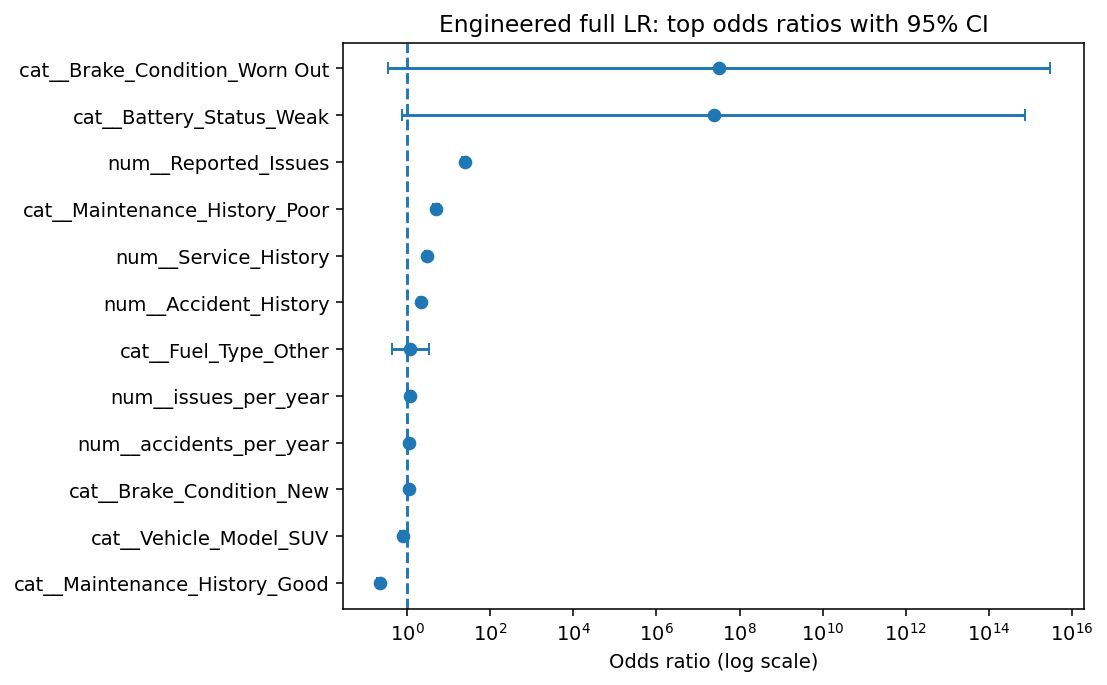

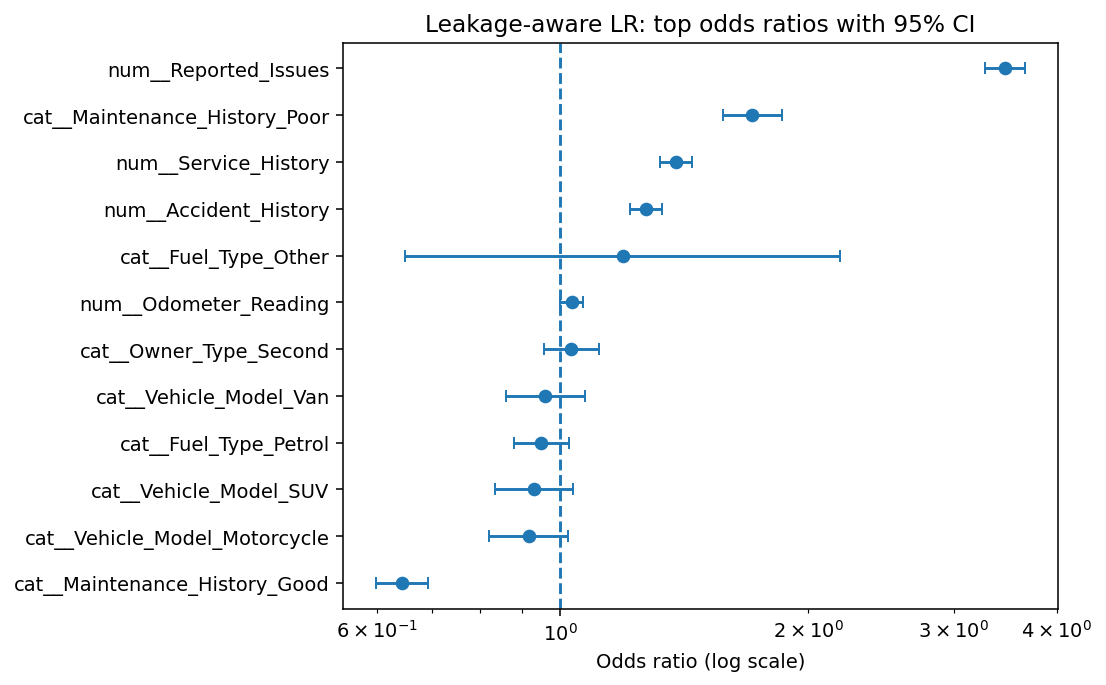

In [36]:
def plot_odds_ratios(or_table: pd.DataFrame, title: str, save_name: str, top_n: int = 12):
    plot_df = or_table.head(top_n).copy().sort_values("odds_ratio")
    lower_err = plot_df["odds_ratio"] - plot_df["ci_lower_95"]
    upper_err = plot_df["ci_upper_95"] - plot_df["odds_ratio"]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(
        plot_df["odds_ratio"],
        plot_df["feature"],
        xerr=[lower_err, upper_err],
        fmt="o",
        capsize=3,
    )
    ax.axvline(1.0, linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("Odds ratio (log scale)")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / save_name, bbox_inches="tight")
    plt.show()


plot_odds_ratios(
    odds_ratio_tables["engineered_full_lr"],
    "Engineered full LR: top odds ratios with 95% CI",
    "engineered_full_lr_odds_ratios.png",
)

plot_odds_ratios(
    odds_ratio_tables["leakage_aware_lr"],
    "Leakage-aware LR: top odds ratios with 95% CI",
    "leakage_aware_lr_odds_ratios.png",
)


## 17) Updated final interpretation

In [37]:
baseline = results["baseline_cleaned_lr"]["tuned_metrics"]
full_model = results["engineered_full_lr"]["tuned_metrics"]
leakage = results["leakage_aware_lr"]["tuned_metrics"]

full_gof = gof_summary.set_index("model").loc["engineered_full_lr"]
leakage_gof = gof_summary.set_index("model").loc["leakage_aware_lr"]

if "best_rfe_row" in globals():
    rfe_interpretation = (
        f"- Formal **RFE validation** now compares all three feature bundles. "
        f"The best RFE-supported bundle is **{best_rfe_row['bundle']}**, using "
        f"**{int(best_rfe_row['selected_transformed_features'])}** of "
        f"**{int(best_rfe_row['total_transformed_features'])}** transformed features, "
        f"with validation F1 = **{best_rfe_row['f1']:.4f}** and validation ROC-AUC = **{best_rfe_row['roc_auc']:.4f}**. "
        f"This best-bundle decision is made by ranking validation F1 first, then ROC-AUC, precision, recall, and finally the smaller selected-feature count as a tie-breaker."
    )
else:
    rfe_interpretation = (
        "- Formal **RFE validation** code has been updated in Section 9.3 to loop over "
        "baseline_cleaned_lr, engineered_full_lr, and leakage_aware_lr; run the notebook with the original CSV "
        "to generate the all-bundle RFE comparison table and best-bundle decision file."
    )

if "best_grid_row" in globals():
    grid_search_interpretation = (
        f"- Full **GridSearchCV** across solver, penalty, C, and class_weight selected "
        f"solver=**{best_grid_row['solver']}**, penalty=**{best_grid_row['penalty']}**, "
        f"C=**{float(best_grid_row['C']):.2f}**, class_weight=**{best_grid_row['class_weight']}**, "
        f"with validation F1 = **{best_grid_row['validation_f1']:.4f}** and validation ROC-AUC = **{best_grid_row['validation_roc_auc']:.4f}**."
    )
else:
    grid_search_interpretation = (
        "- Full **GridSearchCV** code across solver, penalty, C, and class_weight has been added in Section 9.4; "
        "run the notebook with the original CSV to regenerate the grid-search result files."
    )

display(Markdown(
    f'''
### Final findings

**Data cleaning**
- Raw rows: **{cleaning_audit.raw_rows:,}**
- Exact duplicates removed: **{cleaning_audit.duplicate_rows_removed:,}**
- Rows dropped due to missing target: **{cleaning_audit.rows_with_missing_target_dropped:,}**
- Final modeling rows: **{cleaning_audit.final_modeling_rows:,}**
- Invalid date-order cases fixed: **{cleaning_audit.date_inconsistencies_fixed:,}**

**Feature engineering**
- Added the proposal's recommended temporal and usage features:
  `days_since_last_service`, `days_to_warranty_expiry`, `warranty_expired_flag`,
  `mileage_per_year`, `issues_per_year`, `service_per_year`,
  `accidents_per_year`, and `condition_score`.

**Predictive Logistic Regression results**
- **Engineered full LR**  
  Accuracy = **{full_model["accuracy"]:.4f}**  
  Precision = **{full_model["precision"]:.4f}**  
  Recall = **{full_model["recall"]:.4f}**  
  F1-score = **{full_model["f1"]:.4f}**  
  ROC-AUC = **{full_model["roc_auc"]:.4f}**  
  PR-AUC = **{full_model["pr_auc"]:.4f}**

- **Baseline cleaned LR**  
  Accuracy = **{baseline["accuracy"]:.4f}**  
  Precision = **{baseline["precision"]:.4f}**  
  Recall = **{baseline["recall"]:.4f}**  
  F1-score = **{baseline["f1"]:.4f}**  
  ROC-AUC = **{baseline["roc_auc"]:.4f}**

- **Leakage-aware LR**  
  Accuracy = **{leakage["accuracy"]:.4f}**  
  Precision = **{leakage["precision"]:.4f}**  
  Recall = **{leakage["recall"]:.4f}**  
  F1-score = **{leakage["f1"]:.4f}**  
  ROC-AUC = **{leakage["roc_auc"]:.4f}**

**Goodness-of-fit summary**
- **Engineered full LR**  
  LR Chi-Square = **{full_gof["lr_chi2"]:.2f}**  
  LR-test p-value = **{full_gof["lr_p_value"]:.4g}**  
  McFadden pseudo-R² = **{full_gof["mcfadden_r2"]:.4f}**  
  Nagelkerke pseudo-R² = **{full_gof["nagelkerke_r2"]:.4f}**  
  AIC = **{full_gof["aic"]:.2f}**  
  BIC = **{full_gof["bic"]:.2f}**

- **Leakage-aware LR**  
  LR Chi-Square = **{leakage_gof["lr_chi2"]:.2f}**  
  LR-test p-value = **{leakage_gof["lr_p_value"]:.4g}**  
  McFadden pseudo-R² = **{leakage_gof["mcfadden_r2"]:.4f}**  
  Nagelkerke pseudo-R² = **{leakage_gof["nagelkerke_r2"]:.4f}**  
  AIC = **{leakage_gof["aic"]:.2f}**  
  BIC = **{leakage_gof["bic"]:.2f}**

**Experimental setup validation added for the rubric**
- The notebook now includes an explicit **Experimental Setup** section covering data pre-processing, feature extraction, feature selection, classification parameters, and **clustering = not applicable**.
- Formal **L2 hyperparameter validation** on the engineered-full feature set identified the best validation configuration at **C = {best_l2_row["C"]:.2f}** with validation F1 = **{best_l2_row["f1"]:.4f}** and ROC-AUC = **{best_l2_row["roc_auc"]:.4f}**.
- Formal **L1 sparse-model validation** selected **{int(best_sparse_row["selected_transformed_features"])}** transformed features at **C = {best_sparse_row["C"]:.2f}**, providing an explicit feature-selection check for the rubric.
{rfe_interpretation}
{grid_search_interpretation}
- The core reported predictive results remain the same deployment-style Logistic Regression results shown above; the validation tables document the setup more explicitly for the dissertation rubric.
- Section 15 now exports `engineered_full_maintenance_priority_by_row.csv`, assigning every cleaned modeling row a Low / Medium / High `maintenance_priority` from the engineered-full Logistic Regression probability.

**What changed after cleaning?**
- Duplicates disappeared.
- Target labels were standardized to valid binary values.
- Messy categories were collapsed into clean label sets.
- Impossible numeric values and invalid dates were converted to missing and then handled safely in the modeling pipeline.
- The cleaned dataset became suitable for one-hot encoding, imputation, scaling, and Logistic Regression.

**How does Logistic Regression mitigate the research gap?**
- It directly addresses the proposal's gap that the reference study focused mostly on tree-based and distance-based models instead of testing Logistic Regression.
- It produces **interpretable coefficients and odds ratios**.
- It produces **probabilities**, which were converted into Low/Medium/High maintenance-risk bands and a row-level `maintenance_priority` output for every cleaned modeling row using `engineered_full_lr`.
- It supports **leakage-aware evaluation**, which is important because the drop from the full model to the leakage-aware model shows that condition-heavy variables inflate apparent performance.
- It now also includes formal **goodness-of-fit statistics** instead of only predictive accuracy-style metrics.

You can use the figures and tables above directly in your notebook presentation, report, or thesis demo.
'''
))



### Final findings

**Data cleaning**
- Raw rows: **50,900**
- Exact duplicates removed: **900**
- Rows dropped due to missing target: **180**
- Final modeling rows: **49,820**
- Invalid date-order cases fixed: **239**

**Feature engineering**
- Added the proposal's recommended temporal and usage features:
  `days_since_last_service`, `days_to_warranty_expiry`, `warranty_expired_flag`,
  `mileage_per_year`, `issues_per_year`, `service_per_year`,
  `accidents_per_year`, and `condition_score`.

**Predictive Logistic Regression results**
- **Engineered full LR**  
  Accuracy = **0.9507**  
  Precision = **0.9908**  
  Recall = **0.9479**  
  F1-score = **0.9689**  
  ROC-AUC = **0.9833**  
  PR-AUC = **0.9962**

- **Baseline cleaned LR**  
  Accuracy = **0.9503**  
  Precision = **0.9899**  
  Recall = **0.9483**  
  F1-score = **0.9687**  
  ROC-AUC = **0.9833**

- **Leakage-aware LR**  
  Accuracy = **0.7874**  
  Precision = **0.8416**  
  Recall = **0.9084**  
  F1-score = **0.8737**  
  ROC-AUC = **0.8179**

**Goodness-of-fit summary**
- **Engineered full LR**  
  LR Chi-Square = **23209.95**  
  LR-test p-value = **0**  
  McFadden pseudo-R² = **0.7480**  
  Nagelkerke pseudo-R² = **0.8312**  
  AIC = **7890.81**  
  BIC = **8192.13**

- **Leakage-aware LR**  
  LR Chi-Square = **6449.62**  
  LR-test p-value = **0**  
  McFadden pseudo-R² = **0.2079**  
  Nagelkerke pseudo-R² = **0.2944**  
  AIC = **24639.15**  
  BIC = **24890.25**

**Experimental setup validation added for the rubric**
- The notebook now includes an explicit **Experimental Setup** section covering data pre-processing, feature extraction, feature selection, classification parameters, and **clustering = not applicable**.
- Formal **L2 hyperparameter validation** on the engineered-full feature set identified the best validation configuration at **C = 2.00** with validation F1 = **0.9662** and ROC-AUC = **0.9828**.
- Formal **L1 sparse-model validation** selected **32** transformed features at **C = 0.50**, providing an explicit feature-selection check for the rubric.
- Formal **RFE validation** now compares all three feature bundles. The best RFE-supported bundle is **engineered_full_lr**, using **10** of **44** transformed features, with validation F1 = **0.9751** and validation ROC-AUC = **0.9745**. This best-bundle decision is made by ranking validation F1 first, then ROC-AUC, precision, recall, and finally the smaller selected-feature count as a tie-breaker.
- Full **GridSearchCV** across solver, penalty, C, and class_weight selected solver=**saga**, penalty=**l1**, C=**5.00**, class_weight=**None**, with validation F1 = **0.9680** and validation ROC-AUC = **0.9836**.
- The core reported predictive results remain the same deployment-style Logistic Regression results shown above; the validation tables document the setup more explicitly for the dissertation rubric.
- Section 15 now exports `engineered_full_maintenance_priority_by_row.csv`, assigning every cleaned modeling row a Low / Medium / High `maintenance_priority` from the engineered-full Logistic Regression probability.

**What changed after cleaning?**
- Duplicates disappeared.
- Target labels were standardized to valid binary values.
- Messy categories were collapsed into clean label sets.
- Impossible numeric values and invalid dates were converted to missing and then handled safely in the modeling pipeline.
- The cleaned dataset became suitable for one-hot encoding, imputation, scaling, and Logistic Regression.

**How does Logistic Regression mitigate the research gap?**
- It directly addresses the proposal's gap that the reference study focused mostly on tree-based and distance-based models instead of testing Logistic Regression.
- It produces **interpretable coefficients and odds ratios**.
- It produces **probabilities**, which were converted into Low/Medium/High maintenance-risk bands and a row-level `maintenance_priority` output for every cleaned modeling row using `engineered_full_lr`.
- It supports **leakage-aware evaluation**, which is important because the drop from the full model to the leakage-aware model shows that condition-heavy variables inflate apparent performance.
- It now also includes formal **goodness-of-fit statistics** instead of only predictive accuracy-style metrics.

You can use the figures and tables above directly in your notebook presentation, report, or thesis demo.
